# Lecture 5: Hierarchical Models

## Contents

- [5.1 Grouped biomedical data](#section-51)
- [5.2 Pooled model](#section-52)
- [5.3 Unpooled model](#section-53)
- [5.4 From unpooled to hierarchy](#section-54)
- [5.5 Beta parameterizations](#section-55)
- [5.6 Building the hierarchical Beta-Binomial](#section-56)
- [5.7 Fitting and checking the hierarchical model](#section-57)
- [5.8 Posterior interpretation: shrinkage and uncertainty](#section-58)
- [5.9 Benefits and pitfalls](#section-59)
- [5.10 Multiple hierarchy levels](#section-510)
- [5.11 Funnel and non-centering](#section-511)
- [5.12 Workflow summary](#section-512)


## Setup

### Data access policy
This notebook is designed to run cleanly in Colab without requiring students to clone the full course repository. Lecture 5 uses the New York City heart attack deaths data from the `ProbBayes` repository.

The required data filenames and source URLs are listed in the next cell. For each file, the notebook searches in:

1. `.`
2. `./data`
3. `./Data`
4. `../data`
5. `../Data`

If a required file is not found in any of those locations, the notebook downloads it into `.` from the listed source URL.

The setup cell below upgrades Bayesian-analysis packages in Colab only when the runtime is older than the versions expected by this notebook.

In [142]:
import importlib.metadata
import subprocess
import sys

IS_COLAB = "google.colab" in sys.modules
MIN_PACKAGE_VERSIONS = {
    "pymc": "5.25.1",
    "arviz": "0.23.4",
    "arviz-stats": "0.8.0",
    "preliz": "0.24.0",
}


def ensure_colab_packages(package_min_versions):
    if not IS_COLAB:
        return

    from importlib.metadata import PackageNotFoundError, version
    from packaging.version import Version

    packages_to_install = []
    for package_name, min_version in package_min_versions.items():
        try:
            current_version = version(package_name)
        except PackageNotFoundError:
            current_version = None
        if current_version is None or Version(current_version) < Version(min_version):
            packages_to_install.append(f"{package_name}>={min_version}")

    if packages_to_install:
        print("Upgrading Colab packages:", ", ".join(packages_to_install))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *packages_to_install])
        print("Upgrade complete. If imports fail, restart the runtime and run all cells again.")
    else:
        print("Colab runtime already satisfies the notebook package requirements.")


ensure_colab_packages(MIN_PACKAGE_VERSIONS)
print("Colab detected:", IS_COLAB)


Colab detected: False


### Required data files

This data is taken from the Bayesball GitHub: [DeathHeartAttackDataNYCfull.txt](https://github.com/bayesball/ProbBayes/blob/master/data/DeathHeartAttackDataNYCfull.txt). It is not clear what the original provenance of the data is, but NYC publishes data on mortality rates in different hospitals, so it is probably downloaded from their website.

In [143]:
REQUIRED_DATA_FILES = {
    "DeathHeartAttackDataNYCfull.txt": "https://raw.githubusercontent.com/bayesball/ProbBayes/master/data/DeathHeartAttackDataNYCfull.txt",
}


### Resolve required data files

In [144]:
from pathlib import Path
import urllib.request

SEARCH_DIRS = [
    Path("."),
    Path("data"),
    Path("Data"),
    Path("..") / "data",
    Path("..") / "Data",
]


def find_existing_file(filename):
    for directory in SEARCH_DIRS:
        candidate = (directory / filename).resolve()
        if candidate.exists():
            return candidate
    return None


def download_required_file(filename, url):
    destination = (Path(".") / filename).resolve()
    urllib.request.urlretrieve(url, destination)
    return destination


DATA_FILE_PATHS = {}
for filename, url in REQUIRED_DATA_FILES.items():
    existing_path = find_existing_file(filename)
    DATA_FILE_PATHS[filename] = existing_path if existing_path is not None else download_required_file(filename, url)

print("Resolved data files:", {name: str(path) for name, path in DATA_FILE_PATHS.items()})


Resolved data files: {'DeathHeartAttackDataNYCfull.txt': 'D:\\Repositories\\StatisticalComputationAndAnalysis\\Notebooks\\DeathHeartAttackDataNYCfull.txt'}


### Do imports and settings

In [145]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import scipy.stats as stats
from graphviz import Digraph

rng = np.random.default_rng(123)
az.style.use("arviz-whitegrid")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [146]:
POOLED_COLOR = "#f58518"
HOSPITAL_COLOR = "#4c78a8"
HIERARCHICAL_COLOR = "#b279a2"
PCI_COLOR = "#54a24b"
NONPCI_COLOR = "#e45756"
INTERVAL_COLOR = "#8a8a8a"


### Read and clean the data

The file stores hospital names with underscores, which lets us read it as whitespace-delimited text. We keep the original hospital names but also create readable labels for plots.

In [147]:
death_data = pd.read_csv(
    DATA_FILE_PATHS["DeathHeartAttackDataNYCfull.txt"],
    sep=r"\s+",
)

death_data = death_data.assign(
    Hospital=lambda df: df["Hospital"].str.replace("_", " ", regex=False),
    Borough=lambda df: df["Borough"].str.replace("_", " ", regex=False),
    Type=lambda df: df["Type"].map({"P": "PCI", "N": "Non-PCI"}),
)
death_data["DeathRate"] = death_data["Deaths"] / death_data["Cases"]
death_data["HospitalShort"] = death_data["Hospital"].str.replace(" Hospital", "", regex=False)
death_data["HospitalShort"] = death_data["HospitalShort"].str.replace(" Medical Center", " MC", regex=False)
death_data.head()


,Hospital,Borough,Type,Cases,Deaths,DeathRate,HospitalShort
0,Bronx-Lebanon Hospital Center - Concourse Divi...,The Bronx,PCI,209,20,0.095694,Bronx-Lebanon Center - Concourse Division
1,Jacobi Medical Center,The Bronx,Non-PCI,92,5,0.054348,Jacobi MC
2,Lincoln Medical & Mental Health Center,The Bronx,Non-PCI,133,4,0.030075,Lincoln Medical & Mental Health Center
3,Montefiore Med Center - Jack D Weiler Hospital...,The Bronx,PCI,336,18,0.053571,Montefiore Med Center - Jack D Weiler of A Ein...
4,Montefiore Medical Center - Henry & Lucy Moses...,The Bronx,PCI,267,24,0.089888,Montefiore MC - Henry & Lucy Moses Div


In [148]:
death_data[["Cases", "Deaths", "DeathRate"]].describe()


,Cases,Deaths,DeathRate
count,45.000000,45.000000,45.000000
mean,205.222222,15.511111,0.076517
std,141.177015,11.054868,0.027012
min,35.000000,1.000000,0.028571
25%,105.000000,7.000000,0.059259
50%,178.000000,13.000000,0.070175
75%,270.000000,22.000000,0.094828
max,727.000000,46.000000,0.130435


The data come from the hierarchical modeling chapter in *Probability and Bayesian Modeling*. The book first studies the Manhattan subset and then poses the full New York City PCI/non-PCI comparison as an extension.

<a id="section-51"></a>
## 5.1 Grouped biomedical data

Observed hospital death rates differ, but raw rates are noisy because hospitals have different numbers of cases.


Always look at the data first. What is the actual death rate and how much data do we have?

In [149]:
total_cases = int(death_data["Cases"].sum())
total_deaths = int(death_data["Deaths"].sum())
pooled_rate = total_deaths / total_cases

pd.DataFrame({
    "cases": [total_cases],
    "deaths": [total_deaths],
    "observed_death_rate": [pooled_rate],
})


,cases,deaths,observed_death_rate
0,9235,698,0.075582


However, the data is a collection of reported death rates from different hospitals. It looks like there may be some variability across hospitals.

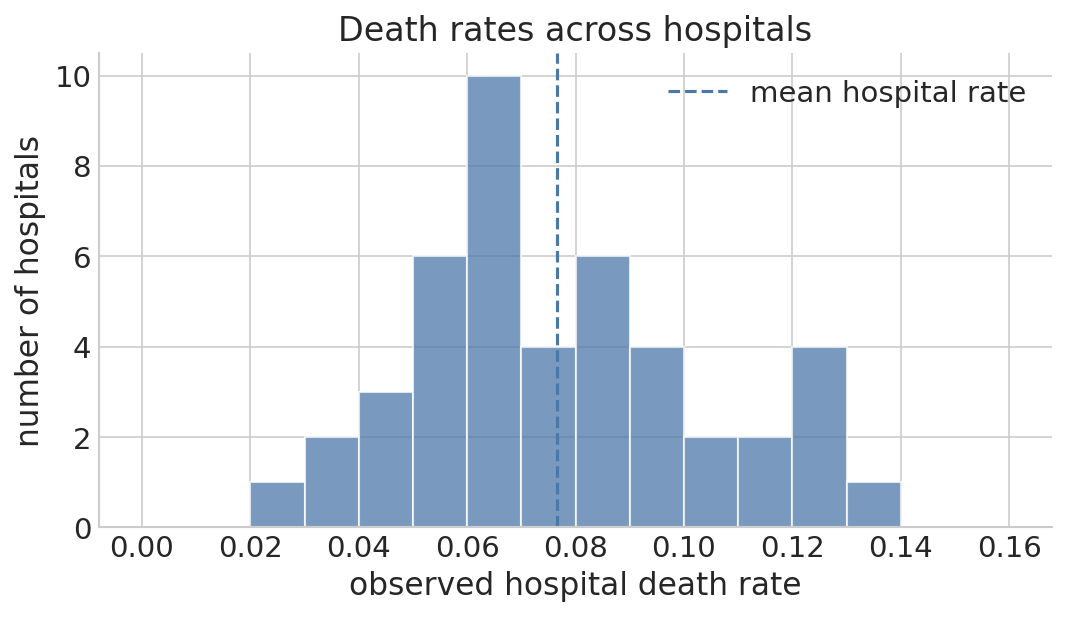

In [150]:
fig, ax = plt.subplots(figsize=(7, 4))
rate_bins = np.linspace(0, 0.16, 17)
ax.hist(death_data["DeathRate"], bins=rate_bins, color=HOSPITAL_COLOR, alpha=0.75, edgecolor="white")
ax.axvline(death_data["DeathRate"].mean(), color=HOSPITAL_COLOR, linestyle="--", label="mean hospital rate")
ax.set(xlabel="observed hospital death rate", ylabel="number of hospitals", title="Death rates across hospitals")
ax.legend()


In fact, some hospitals are set up for dealing with heart attacks. PCI stands for percutaneous cardiac intervention and represents a relatively new technology for dealing with cardiac arrest.

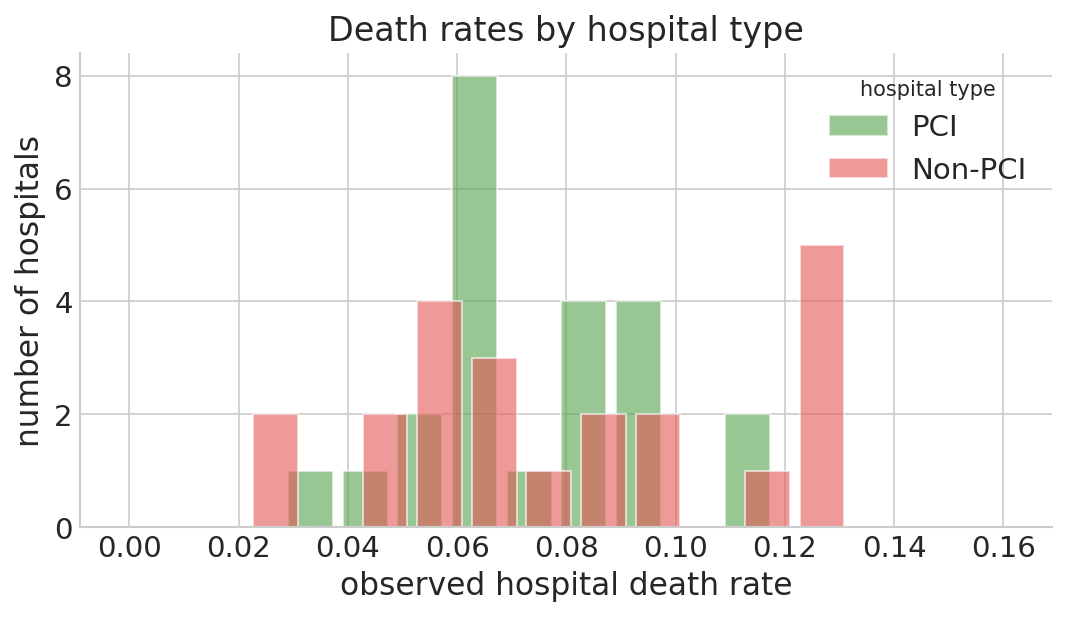

In [151]:
fig, ax = plt.subplots(figsize=(7, 4))

_original_hist = ax.hist
_stagger_frac = {"PCI": -0.18, "Non-PCI": 0.18}

def _staggered_hist(x, *args, **kwargs):
    bins = kwargs.get("bins", None)
    label = kwargs.get("label", "")
    if bins is not None:
        bins = np.asarray(bins, dtype=float)
        if bins.ndim == 1 and bins.size > 1:
            bin_width = np.diff(bins).mean()
            kwargs["bins"] = bins + _stagger_frac.get(label, 0.0) * bin_width
    kwargs.setdefault("rwidth", 0.82)  # thinner bars
    return _original_hist(x, *args, **kwargs)

ax.hist = _staggered_hist
for hospital_type, color in [("PCI", PCI_COLOR), ("Non-PCI", NONPCI_COLOR)]:
    rows = death_data["Type"] == hospital_type
    ax.hist(
        death_data.loc[rows, "DeathRate"],
        bins=rate_bins,
        color=color,
        alpha=0.6,
        edgecolor="white",
        label=hospital_type,
    )
ax.set(xlabel="observed hospital death rate", ylabel="number of hospitals", title="Death rates by hospital type")
ax.legend(title="hospital type")


C:\Users\User\AppData\Local\Temp\ipykernel_17968\1121404819.py:27: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


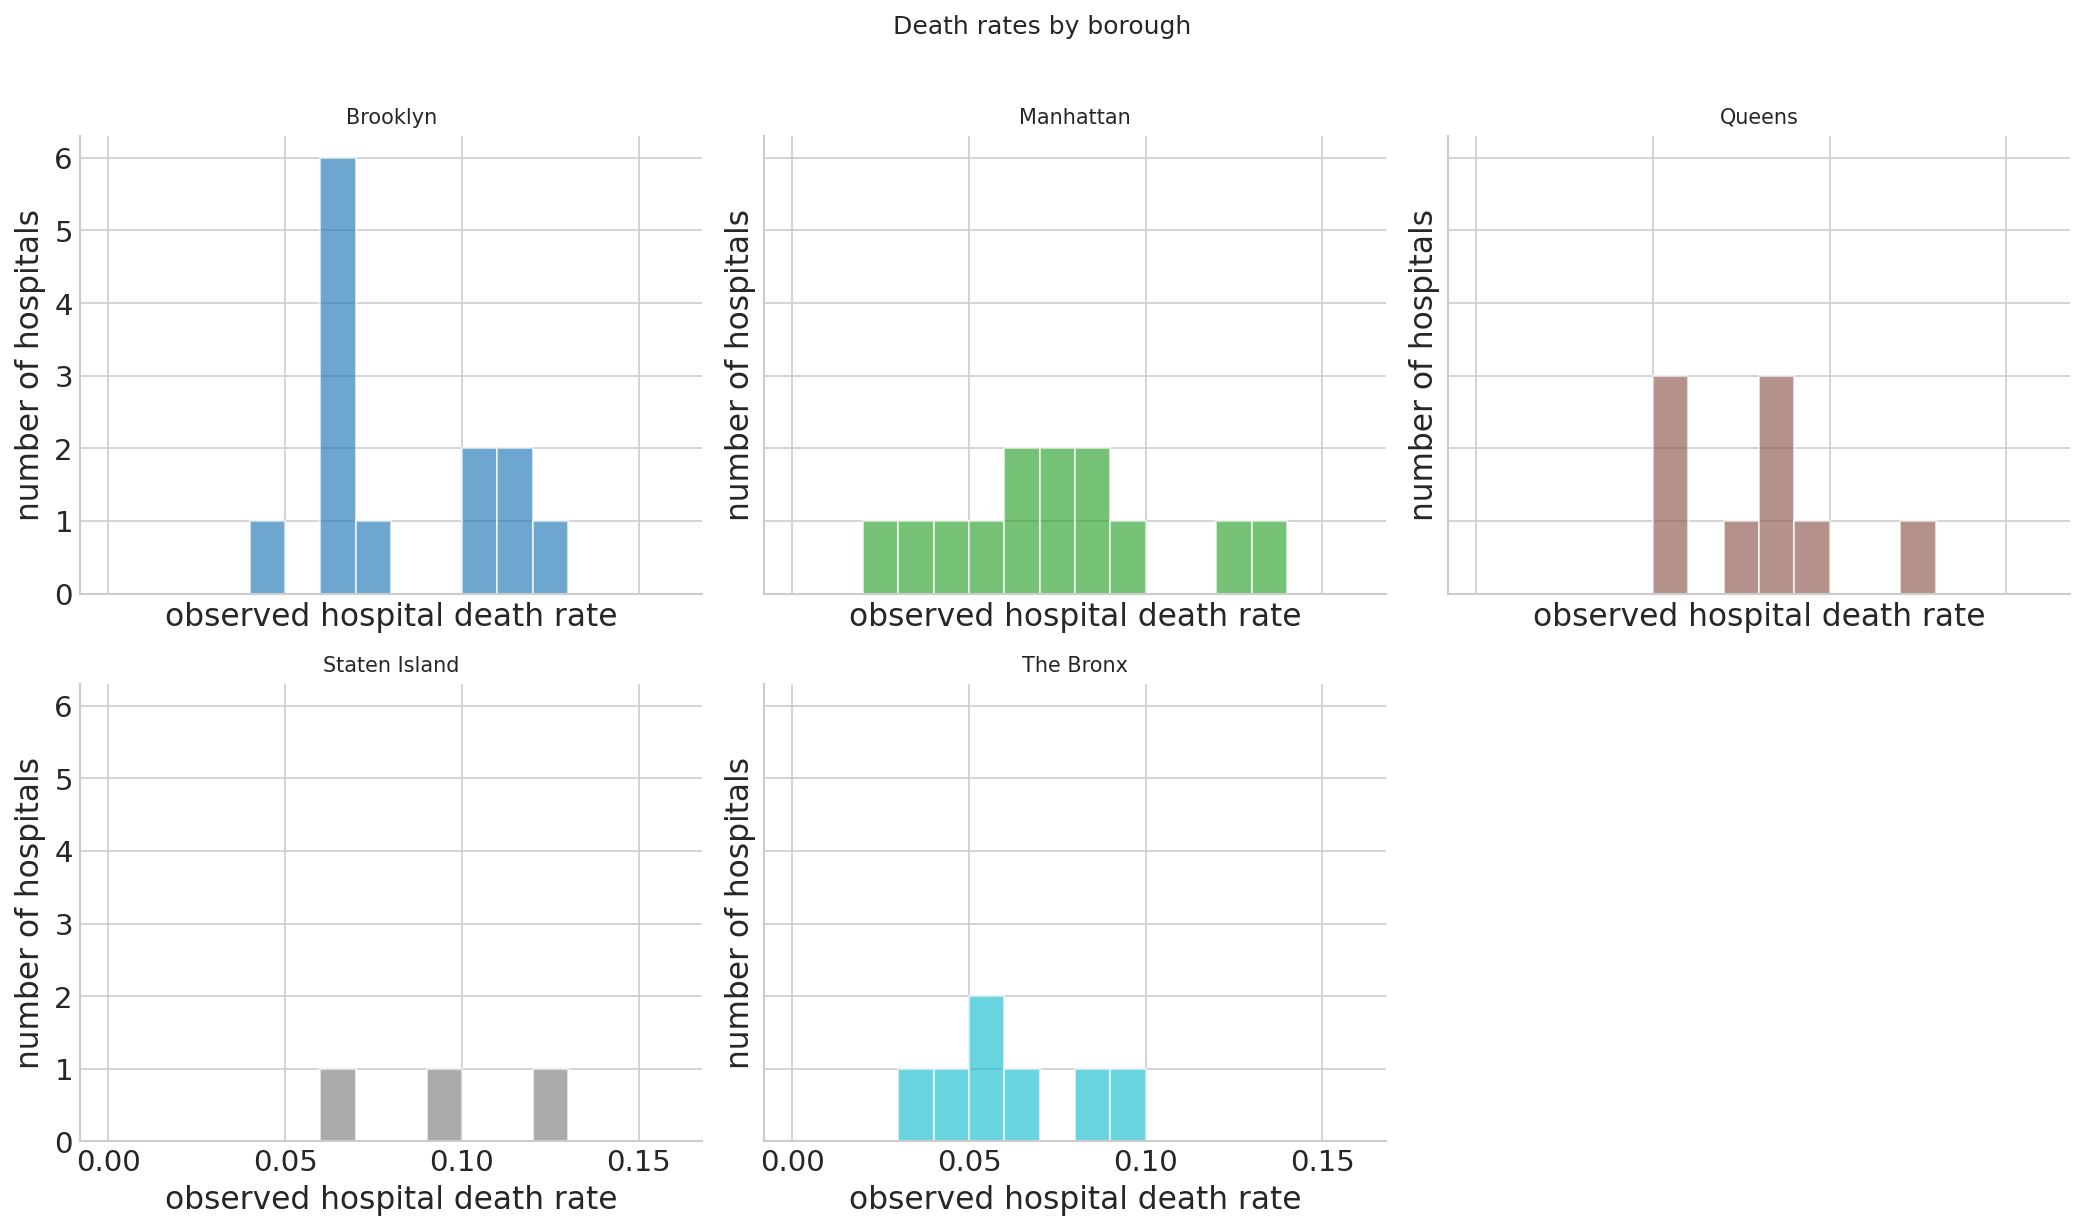

In [152]:
boroughs = pd.Index(death_data["Borough"].dropna().unique()).sort_values().to_numpy()
rate_bins = np.linspace(0, 0.16, 17)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, len(boroughs)))

for i, (borough, color) in enumerate(zip(boroughs, colors)):
    ax = axes[i]
    rows = death_data["Borough"] == borough
    ax.hist(
        death_data.loc[rows, "DeathRate"],
        bins=rate_bins,
        color=color,
        alpha=0.65,
        edgecolor="white",
    )
    ax.set_title(borough, fontsize=10)
    ax.set_xlabel("observed hospital death rate")
    ax.set_ylabel("number of hospitals")

# hide any unused subplot(s)
for j in range(len(boroughs), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Death rates by borough", y=1.02)
fig.tight_layout()
plt.show()
boroughs = pd.Index(death_data["Borough"].dropna().unique()).sort_values().to_numpy()



<a id="section-52"></a>
## 5.2 Pooled model

Complete pooling estimates one shared death probability for all hospitals.


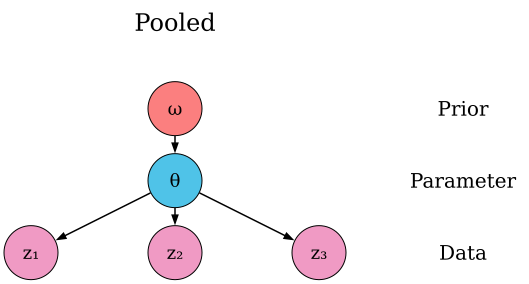

In [153]:
pooled_diagram = Digraph("pooled_diagram", engine="neato")
pooled_diagram.attr(bgcolor="white", splines="line")
pooled_diagram.attr("node", fontname="DejaVu Serif", fontsize="18")
pooled_diagram.attr("edge", arrowsize="0.8", penwidth="1.5")

constant_style = {"shape": "circle", "style": "filled", "fillcolor": "#fb7f7f", "width": "0.75", "fixedsize": "true"}
parameter_style = {"shape": "circle", "style": "filled", "fillcolor": "#4fc3e8", "width": "0.75", "fixedsize": "true"}
data_style = {"shape": "circle", "style": "filled", "fillcolor": "#f09ac4", "width": "0.75", "fixedsize": "true"}
label_style = {"shape": "plaintext", "fontname": "DejaVu Serif", "fontsize": "20"}

# Three rows: ω top-center, θ middle-center, z₁ z₂ z₃ bottom row.
# z columns at x=1,3,5 → θ and ω at x=3 (exact center).
x_cols  = [1.0, 3.0, 5.0]
label_x = 7.0

pooled_diagram.node("title",           "Pooled",    pos="3.0,3.2!", shape="plaintext", fontsize="24", fontname="DejaVu Serif")
pooled_diagram.node("prior",           "ω",         pos="3.0,2!",   **constant_style)
pooled_diagram.node("theta",           "θ",         pos="3.0,1!",   **parameter_style)
pooled_diagram.node("prior_label",     "Prior",     pos=f"{label_x},2!", **label_style)
pooled_diagram.node("parameter_label", "Parameter", pos=f"{label_x},1!", **label_style)
pooled_diagram.node("data_label",      "Data",      pos=f"{label_x},0!", **label_style)

for idx, (x, lbl) in enumerate(zip(x_cols, ["z₁", "z₂", "z₃"]), 1):
    pooled_diagram.node(f"z{idx}", lbl, pos=f"{x},0!", **data_style)

pooled_diagram.edge("prior", "theta")
for idx in range(1, 4):
    pooled_diagram.edge("theta", f"z{idx}")

pooled_diagram


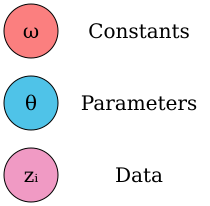

In [154]:
legend_diagram = Digraph("legend_diagram", engine="neato")
legend_diagram.attr(bgcolor="white")
legend_diagram.attr("node", fontname="DejaVu Serif", fontsize="20")

for row_idx, (name, symbol, label, style) in enumerate([
    ("constant",  "ω",  "Constants",  constant_style),
    ("parameter", "θ",  "Parameters", parameter_style),
    ("data",      "zᵢ", "Data",       data_style),
]):
    y = 2 - row_idx
    legend_diagram.node(f"{name}_node",  symbol, pos=f"0,{y}!", **style)
    legend_diagram.node(f"{name}_label", label,  pos=f"1.5,{y}!", shape="plaintext", fontname="DejaVu Serif", fontsize="20")

legend_diagram


Examination of the data suggests that the range of 0.01 to 0.3 is a minimally informative prior.

,parameter,value
0,alpha,2.441527
1,beta,14.806674


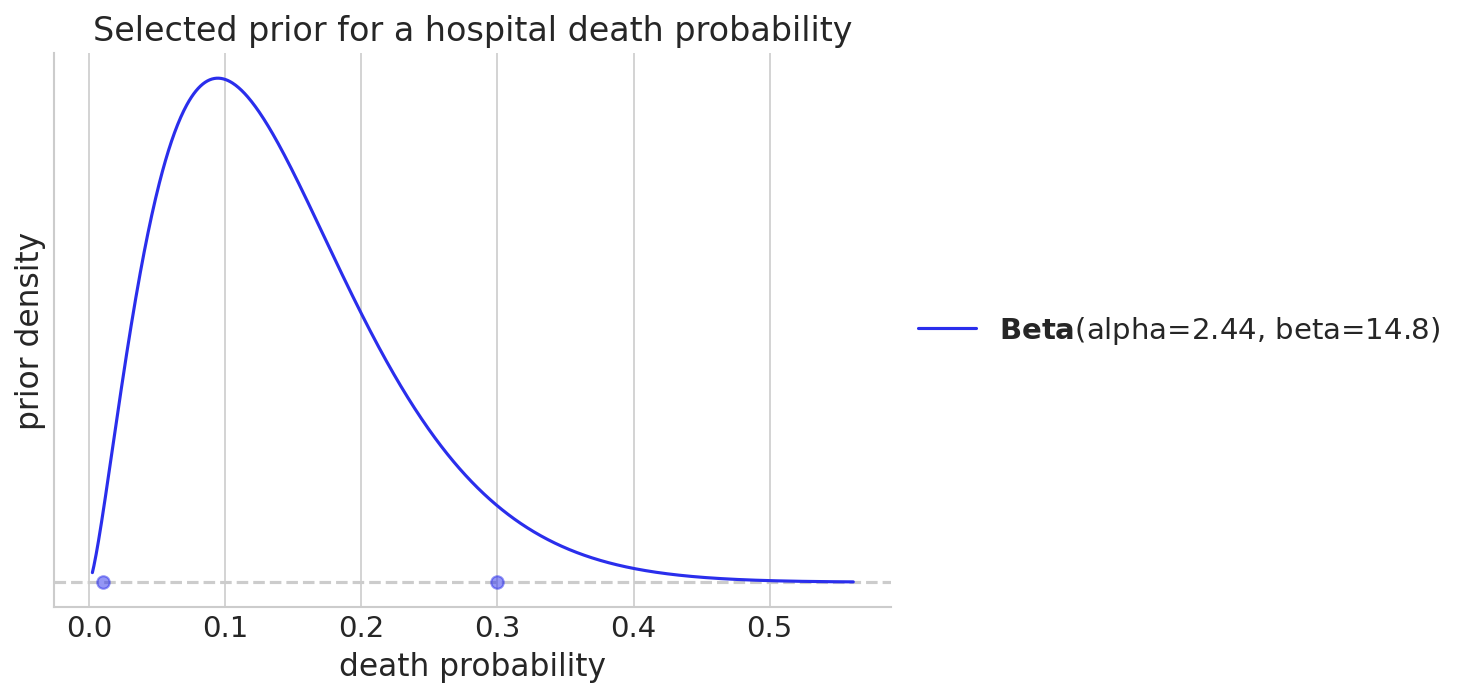

In [155]:
death_rate_prior, ax = pz.maxent(
    pz.Beta(),
    lower=0.01,
    upper=0.30,
    mass=0.95,
    plot=True,
)
omega_alpha = float(death_rate_prior.alpha)
omega_beta = float(death_rate_prior.beta)

ax.set(xlabel="death probability", ylabel="prior density", title="Selected prior for a hospital death probability")

pd.DataFrame({
    "parameter": ["alpha", "beta"],
    "value": [omega_alpha, omega_beta],
})


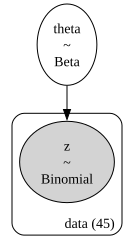

In [156]:
death_data = death_data.sort_values("DeathRate").reset_index(drop=True)
hospital_names = death_data["HospitalShort"].to_numpy()
hospital_labels = np.array([f"H{idx + 1}" for idx in range(len(death_data))])
hospital_idx = np.arange(len(death_data))
cases = death_data["Cases"].to_numpy()
deaths = death_data["Deaths"].to_numpy()
observed_rate = deaths / cases

coords = {"data": hospital_names}

with pm.Model(coords=coords) as pooled_binomial_model:
    theta = pm.Beta("theta", alpha=omega_alpha, beta=omega_beta)
    z = pm.Binomial("z", n=cases, p=theta, observed=deaths, dims="data")


pm.model_to_graphviz(pooled_binomial_model)

In [157]:
with pooled_binomial_model:
    idata_pooled = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=123,
        progressbar=False,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.


In [158]:
theta_pooled = idata_pooled.posterior["theta"]
pooled_samples = az.extract(idata_pooled, var_names="theta").to_numpy()
pooled_posterior_mean = float(theta_pooled.mean().to_numpy())
pooled_hdi = az.hdi(theta_pooled, hdi_prob=0.94).theta.to_numpy()

az.summary(idata_pooled, var_names=["theta"], hdi_prob=0.94)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.076,0.003,0.071,0.081,0.0,0.0,1235.0,2392.0,1.01


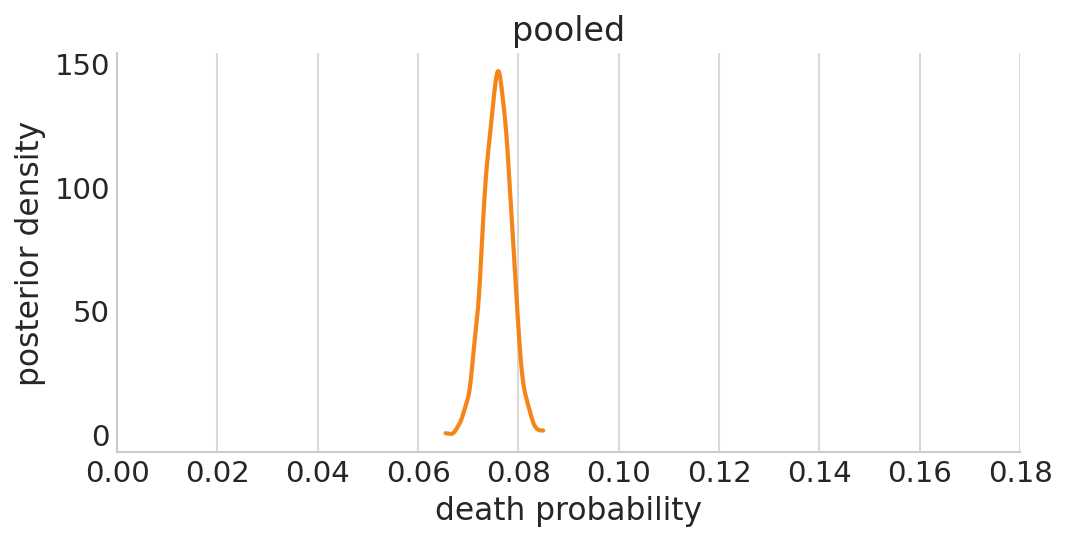

In [159]:
fig, ax = plt.subplots(figsize=(7, 3.5))
az.plot_kde(
    pooled_samples,
    ax=ax,
    plot_kwargs={"color": POOLED_COLOR, "linewidth": 2},
)
ax.set(title="pooled", xlabel="death probability", ylabel="posterior density")
ax.set_xlim(0, 0.18)
ax.grid(axis="x", color="0.85", linewidth=1)
ax.grid(axis="y", visible=False)


Before using the posterior, check what the pooled model expected to see before looking at the deaths.

Sampling: [theta, z]


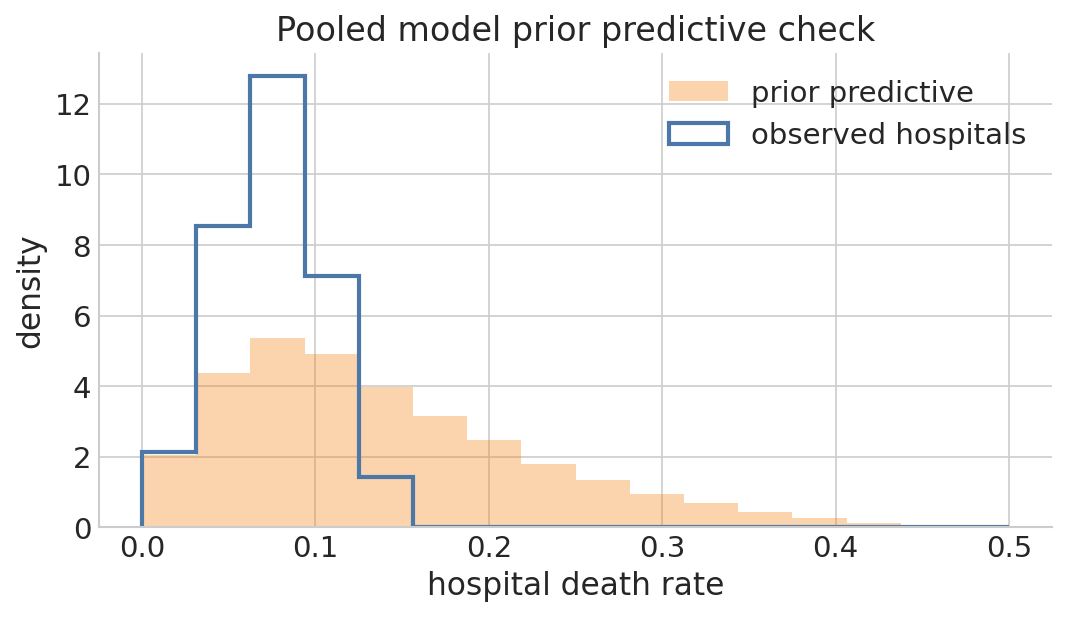

In [160]:
rate_bins_priorp = np.linspace(0, 0.5, 17)

with pooled_binomial_model:
    idata_pooled_prior = pm.sample_prior_predictive(
        samples=1000, random_seed=124,
    )

prior_predictive_z = az.extract(idata_pooled_prior, group="prior_predictive", var_names="z")
prior_predictive_rate = (prior_predictive_z / cases[:, None]).to_numpy().ravel()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(prior_predictive_rate, bins=rate_bins_priorp, density=True, color=POOLED_COLOR, alpha=0.35, label="prior predictive")
ax.hist(observed_rate, bins=rate_bins_priorp, density=True, histtype="step", color=HOSPITAL_COLOR, linewidth=2, label="observed hospitals")
ax.set(xlabel="hospital death rate", ylabel="density", title="Pooled model prior predictive check")
ax.legend()


After fitting, the posterior predictive distribution asks whether the pooled model can reproduce the observed spread across hospitals.

Sampling: [z]


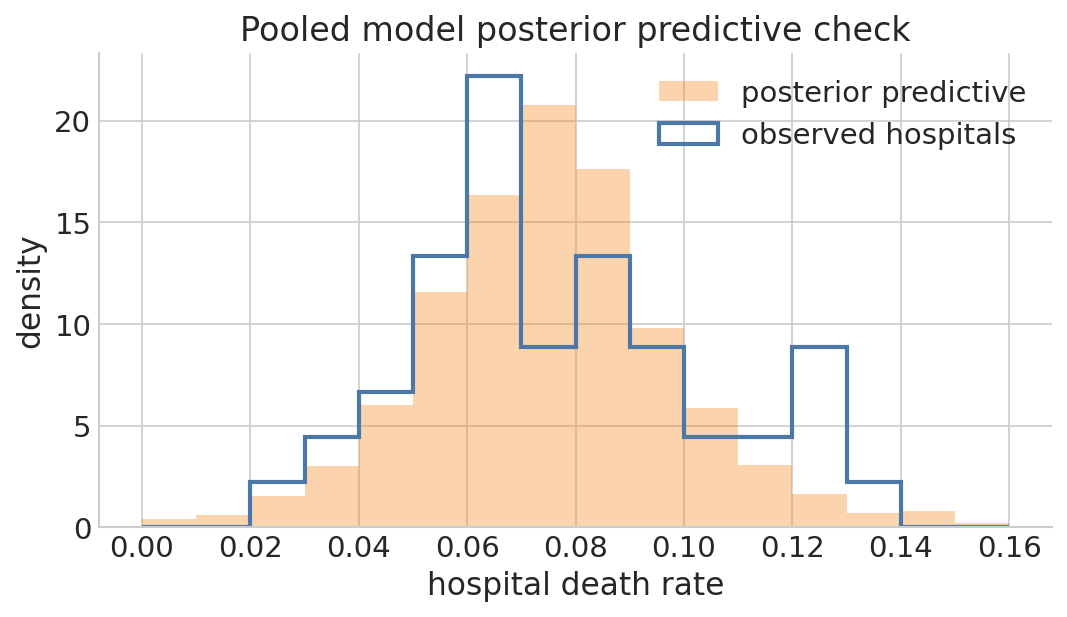

In [161]:
with pooled_binomial_model:
    idata_pooled_posterior = pm.sample_posterior_predictive(
        idata_pooled, random_seed=125, progressbar=False,
    )

posterior_predictive_z = az.extract(idata_pooled_posterior, group="posterior_predictive", var_names="z")
posterior_predictive_rate = (posterior_predictive_z / cases[:, None]).to_numpy().ravel()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(posterior_predictive_rate, bins=rate_bins, density=True, color=POOLED_COLOR, alpha=0.35, label="posterior predictive")
ax.hist(observed_rate, bins=rate_bins, density=True, histtype="step", color=HOSPITAL_COLOR, linewidth=2, label="observed hospitals")
ax.set(xlabel="hospital death rate", ylabel="density", title="Pooled model posterior predictive check")
ax.legend()


The pooled model is precise, but it answers a narrow question: the average death probability if all hospital labels are ignored.

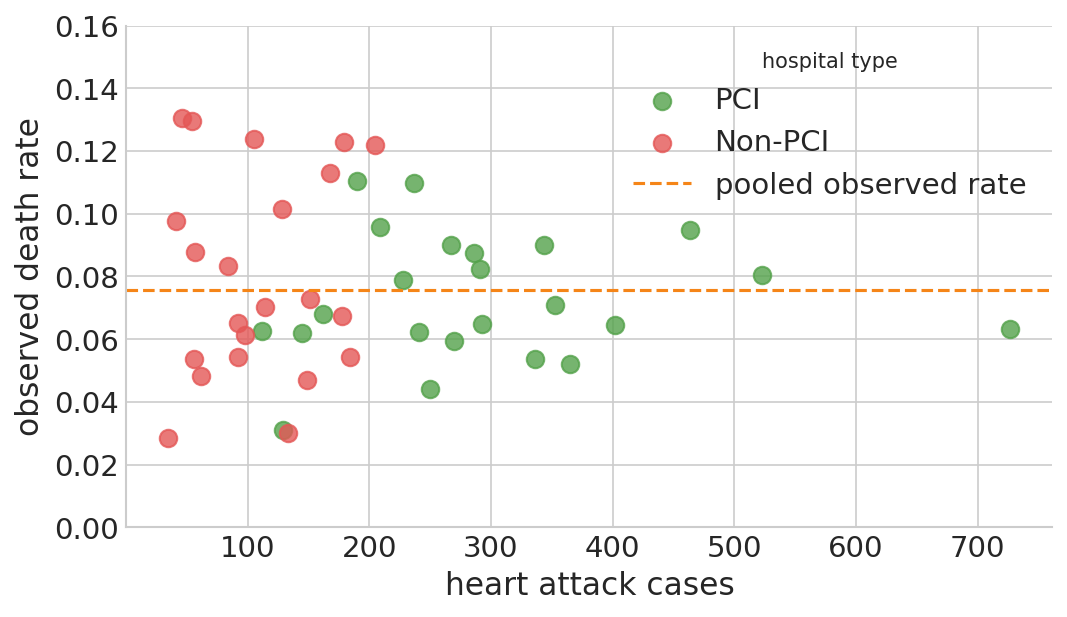

In [162]:
fig, ax = plt.subplots(figsize=(7, 4))
for hospital_type, color in [("PCI", PCI_COLOR), ("Non-PCI", NONPCI_COLOR)]:
    rows = death_data["Type"] == hospital_type
    ax.scatter(
        death_data.loc[rows, "Cases"],
        death_data.loc[rows, "DeathRate"],
        s=70,
        alpha=0.8,
        color=color,
        label=hospital_type,
    )
ax.axhline(pooled_rate, color=POOLED_COLOR, linestyle="--", label="pooled observed rate")
ax.set(xlabel="heart attack cases", ylabel="observed death rate", ylim=(0, 0.16))
ax.legend(title="hospital type")


The plot reveals the main modeling issue. Some hospitals have higher observed death rates than others, and the uncertainty is not the same for hospitals with 35 cases and hospitals with 727 cases.

<a id="section-53"></a>
## 5.3 Unpooled model

Now reveal the hospital labels. A separate analysis estimates each hospital's death probability independently.


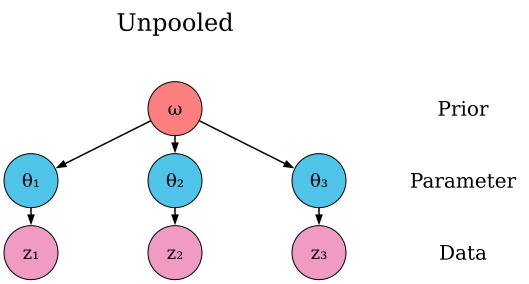

In [163]:
unpooled_diagram = Digraph("unpooled_diagram", engine="neato")
unpooled_diagram.attr(bgcolor="white", splines="line")
unpooled_diagram.attr("node", fontname="DejaVu Serif", fontsize="18")
unpooled_diagram.attr("edge", arrowsize="0.8", penwidth="1.5")

constant_style = {"shape": "circle", "style": "filled", "fillcolor": "#fb7f7f", "width": "0.75", "fixedsize": "true"}
parameter_style = {"shape": "circle", "style": "filled", "fillcolor": "#4fc3e8", "width": "0.75", "fixedsize": "true"}
data_style = {"shape": "circle", "style": "filled", "fillcolor": "#f09ac4", "width": "0.75", "fixedsize": "true"}
label_style = {"shape": "plaintext", "fontname": "DejaVu Serif", "fontsize": "20"}

# Three rows: ω top-center, θ middle, z bottom.
# Columns at x=1,3,5 match the pooled diagram; ω at x=3 is exactly centered.
x_cols  = [1.0, 3.0, 5.0]
label_x = 7.0

unpooled_diagram.node("title",       "Unpooled",  pos="3.0,3.2!", shape="plaintext", fontsize="24", fontname="DejaVu Serif")
unpooled_diagram.node("omega",       "ω",         pos="3.0,2!",   **constant_style)
unpooled_diagram.node("prior_label", "Prior",     pos=f"{label_x},2!", **label_style)
unpooled_diagram.node("param_label", "Parameter", pos=f"{label_x},1!", **label_style)
unpooled_diagram.node("data_label",  "Data",      pos=f"{label_x},0!", **label_style)

for idx, (x, tl, zl) in enumerate(
    zip(x_cols, ["θ₁", "θ₂", "θ₃"], ["z₁", "z₂", "z₃"]), 1
):
    unpooled_diagram.node(f"theta{idx}", tl, pos=f"{x},1!", **parameter_style)
    unpooled_diagram.node(f"z{idx}",     zl, pos=f"{x},0!", **data_style)
    unpooled_diagram.edge("omega",       f"theta{idx}")
    unpooled_diagram.edge(f"theta{idx}", f"z{idx}")

unpooled_diagram


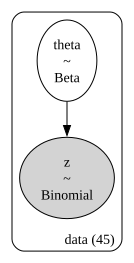

In [164]:
with pm.Model(coords=coords) as unpooled_binomial_model:
    theta = pm.Beta("theta", alpha=omega_alpha, beta=omega_beta, dims="data")
    z = pm.Binomial("z", n=cases, p=theta, observed=deaths, dims="data")

pm.model_to_graphviz(unpooled_binomial_model)

In [165]:
with unpooled_binomial_model:
    idata_unpooled = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=234,
        progressbar=False,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 24 seconds.


In [166]:
theta_unpooled = idata_unpooled.posterior["theta"]
separate_mean = theta_unpooled.mean(("chain", "draw")).to_numpy()
separate_interval = az.hdi(theta_unpooled, hdi_prob=0.94).theta.to_numpy()

selected_hospitals = rng.choice(hospital_names, size=5, replace=False)
summary_coords = {"data": selected_hospitals}
az.summary(idata_unpooled, coords=summary_coords, hdi_prob=0.94)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta[Bellevue Center],0.044,0.017,0.014,0.075,0.0,0.000,4308.0,2655.0,1.0
theta[Lenox Hill],0.083,0.017,0.050,0.115,0.0,0.000,5627.0,2932.0,1.0
theta[Harlem Center],0.065,0.033,0.013,0.126,0.0,0.001,3974.0,2424.0,1.0
theta[Forest Hills],0.123,0.022,0.082,0.167,0.0,0.000,5764.0,2549.0,1.0
theta[Metropolitan Center],0.094,0.029,0.045,0.149,0.0,0.000,5653.0,2728.0,1.0


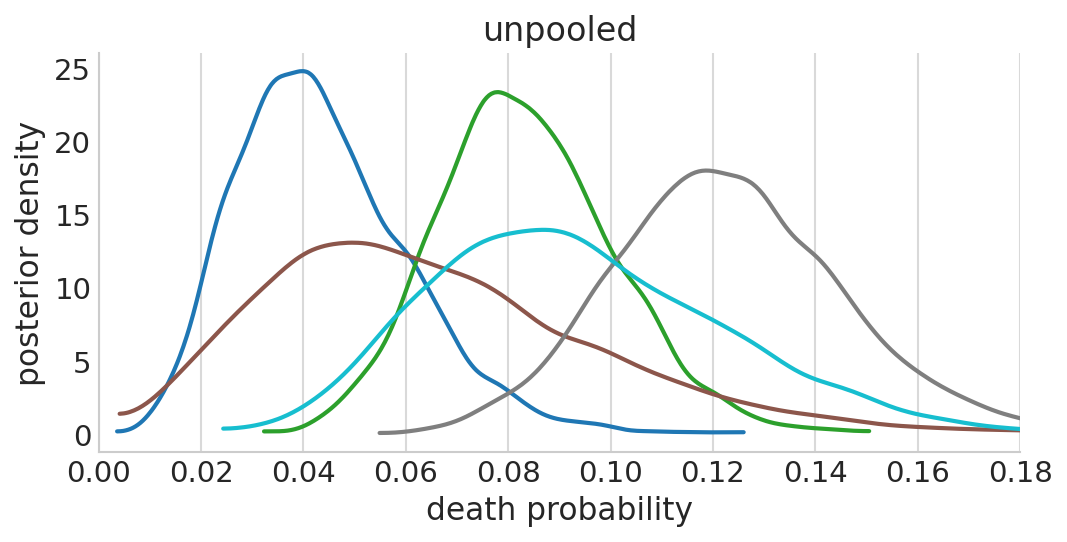

In [167]:
fig, ax = plt.subplots(figsize=(7, 3.5))
selected_hospital_colors = dict(zip(selected_hospitals, plt.cm.tab10(np.linspace(0, 1, len(selected_hospitals)))))
theta_unpooled_samples = az.extract(idata_unpooled, var_names="theta")

for hospital in selected_hospitals:
    hospital_samples = theta_unpooled_samples.sel(data=hospital).to_numpy()
    az.plot_kde(
        hospital_samples,
        ax=ax,
        plot_kwargs={"color": selected_hospital_colors[hospital], "linewidth": 2, "label": hospital},
    )

ax.set(title="unpooled", xlabel="death probability", ylabel="posterior density")
ax.set_xlim(0, 0.18)
ax.grid(axis="x", color="0.85", linewidth=1)
ax.grid(axis="y", visible=False)
legend = ax.get_legend()
if legend is not None:
    legend.remove()
# ax.legend(title="hospital", bbox_to_anchor=(1.02, 1), loc="upper left")


The separate estimates are easy to compute, but they do not share information across hospitals.

<a id="section-54"></a>
## 5.4 From unpooled to hierarchy

The unpooled model gives each hospital its own death probability, but all hospital probabilities still came from the same fixed prior. A hierarchical model turns the prior distribution itself into something the data can learn.

For hospital `i`,

`z_i ~ Binomial(Cases_i, theta_i)`

and the `theta` values share a common Beta distribution:

`theta_i ~ Beta(mu=mu_theta, nu=nu_theta)`.

The parameter `mu_theta` is the city-wide mean death probability. The parameter `nu_theta` is the concentration: larger values make `theta` values more similar to one another.


<a id="section-55"></a>
## 5.5 Beta parameterizations

The same Beta distribution can be written with three equivalent sets of parameters.

- `alpha`, `beta`: equivalent prior successes and failures.
- `mu`, `nu`: mean and concentration, with `alpha = mu * nu` and `beta = (1 - mu) * nu`.
- `mu`, `sigma`: mean and standard deviation.

The slides show the same three distributions in each parameterization. In the hierarchical model we will use `mu` and `nu`, because those map cleanly to the average hospital rate and the amount of hospital-to-hospital similarity.

In [ ]:
omega_mu = omega_alpha / (omega_alpha + omega_beta)
omega_nu = omega_alpha + omega_beta


def plot_beta_parameterization(distributions):
    fig, ax = plt.subplots(figsize=(9, 4))
    for distribution in distributions:
        distribution.plot_pdf(
            ax=ax,
            support=(0.001, 0.999),
            baseline=False,
            linewidth=2,
        )
    ax.set(xlim=(0, 1))
    ax.set_ylim(bottom=0)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.tight_layout()
    return fig, ax


alpha_beta_examples = [
    pz.Beta(alpha=0.5, beta=0.5),
    pz.Beta(alpha=5, beta=5),
    pz.Beta(alpha=2, beta=5),
]

plot_beta_parameterization(alpha_beta_examples);

In [ ]:
mu_nu_examples = [
    pz.Beta(mu=0.5, nu=1),
    pz.Beta(mu=0.5, nu=10),
    pz.Beta(mu=2 / 7, nu=7),
]

plot_beta_parameterization(mu_nu_examples);

In [ ]:
mu_sigma_examples = [
    pz.Beta(mu=0.5, sigma=np.sqrt(0.5 * 0.5 / (1 + 1))),
    pz.Beta(mu=0.5, sigma=np.sqrt(0.5 * 0.5 / (10 + 1))),
    pz.Beta(mu=2 / 7, sigma=np.sqrt((2 / 7) * (5 / 7) / (7 + 1))),
]

plot_beta_parameterization(mu_sigma_examples);

In PyMC we will write the group prior directly as:

```python
pm.Beta("theta", mu=mu_theta, nu=nu_theta, dims="data")
```

That keeps the model code close to the story: each observation has a death probability `theta`, and the prior parameters `mu_theta` and `nu_theta` describe the shared population.

<a id="section-56"></a>
## 5.6 Building the hierarchical Beta-Binomial

The graphical model translates into PyMC code by giving `theta` a learned Beta distribution and placing hyperpriors on the shared mean and concentration.


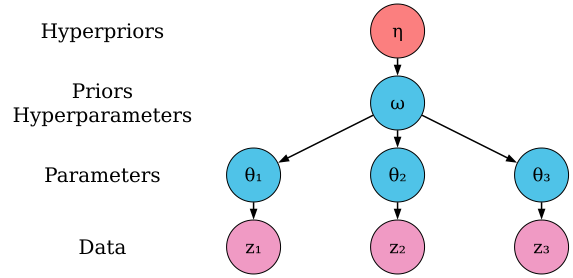

In [170]:
hierarchical_diagram = Digraph("hierarchical_diagram", engine="neato")
hierarchical_diagram.attr(bgcolor="white", splines="line")
hierarchical_diagram.attr("node", fontname="DejaVu Serif", fontsize="18")
hierarchical_diagram.attr("edge", arrowsize="0.8", penwidth="1.5")

constant_style = {"shape": "circle", "style": "filled", "fillcolor": "#fb7f7f", "width": "0.75", "fixedsize": "true"}
parameter_style = {"shape": "circle", "style": "filled", "fillcolor": "#4fc3e8", "width": "0.75", "fixedsize": "true"}
data_style = {"shape": "circle", "style": "filled", "fillcolor": "#f09ac4", "width": "0.75", "fixedsize": "true"}
label_style = {"shape": "plaintext", "fontname": "DejaVu Serif", "fontsize": "20"}

x_cols = [1.0, 3.0, 5.0]
label_x = -1.1

hierarchical_diagram.node("hyperprior_label", "Hyperpriors", pos=f"{label_x},3!", **label_style)
hierarchical_diagram.node("prior_label", "Priors\nHyperparameters", pos=f"{label_x},2!", **label_style)
hierarchical_diagram.node("parameter_label", "Parameters", pos=f"{label_x},1!", **label_style)
hierarchical_diagram.node("data_label", "Data", pos=f"{label_x},0!", **label_style)

hierarchical_diagram.node("eta", "η", pos="3.0,3!", **constant_style)
hierarchical_diagram.node("omega", "ω", pos="3.0,2!", **parameter_style)

for idx, (x, theta_label, z_label) in enumerate(
    zip(x_cols, ["θ₁", "θ₂", "θ₃"], ["z₁", "z₂", "z₃"]), start=1
):
    hierarchical_diagram.node(f"theta{idx}", theta_label, pos=f"{x},1!", **parameter_style)
    hierarchical_diagram.node(f"z{idx}", z_label, pos=f"{x},0!", **data_style)
    hierarchical_diagram.edge("omega", f"theta{idx}")
    hierarchical_diagram.edge(f"theta{idx}", f"z{idx}")

hierarchical_diagram.edge("eta", "omega")

hierarchical_diagram


### Choosing hyperpriors in mean-concentration form

The prior chosen above was stored as `omega_alpha` and `omega_beta`. For the hierarchical model we rewrite the same Beta distribution in mean-concentration form, where `mu_mu_theta = alpha / (alpha + beta)` and `nu_mu_theta = alpha + beta`.

To choose a scale for `nu_theta`, we ask PreliZ for a Beta distribution with mean `mu_mu_theta` and width `sigma_theta`. The concentration of that Beta distribution is then a reasonable prior scale for `nu_theta`, since it is around the average concentration we expect before seeing the hospital-level data.


In [171]:
mu_mu_theta = omega_alpha / (omega_alpha + omega_beta)
nu_mu_theta = omega_alpha + omega_beta

sigma_theta = 0.05 # More than the actual deviation of the death rates
implied_theta_prior = pz.Beta(mu=mu_mu_theta, sigma=sigma_theta)
sigma_nu_theta = float(implied_theta_prior.nu)

pd.DataFrame({
    "parameter": ["mu_mu_theta", "nu_mu_theta", "sigma_theta", "nu_theta_alpha", "nu_theta_beta", "sigma_nu_theta"],
    "value": [mu_mu_theta, nu_mu_theta, sigma_theta, implied_theta_prior.alpha, implied_theta_prior.beta, sigma_nu_theta],
})


,parameter,value
0,mu_mu_theta,0.141553
1,nu_mu_theta,17.248201
2,sigma_theta,0.050000
3,nu_theta_alpha,6.738774
4,nu_theta_beta,40.867393
5,sigma_nu_theta,47.606166


The `HalfNormal(sigma_nu_theta)` prior says that before seeing the data we expect some hospital-to-hospital similarity, but we still allow positive concentrations around the scale implied by a broad Beta distribution for hospital rates.


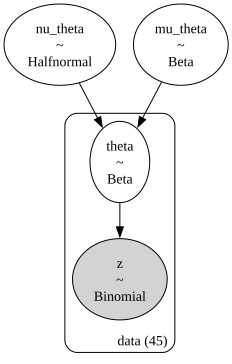

In [172]:
coords = {"data": hospital_names}

with pm.Model(coords=coords) as hospital_beta_binomial_model:
    mu_theta = pm.Beta("mu_theta", mu=mu_mu_theta, nu=nu_mu_theta)
    nu_theta = pm.HalfNormal("nu_theta", sigma=sigma_nu_theta)

    theta = pm.Beta("theta", mu=mu_theta, nu=nu_theta, dims="data")
    z = pm.Binomial("z", n=cases, p=theta, observed=deaths, dims="data")

pm.model_to_graphviz(hospital_beta_binomial_model)


Sampling: [mu_theta, nu_theta, theta, z]
C:\Users\User\AppData\Local\Temp\ipykernel_17968\927620101.py:19: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


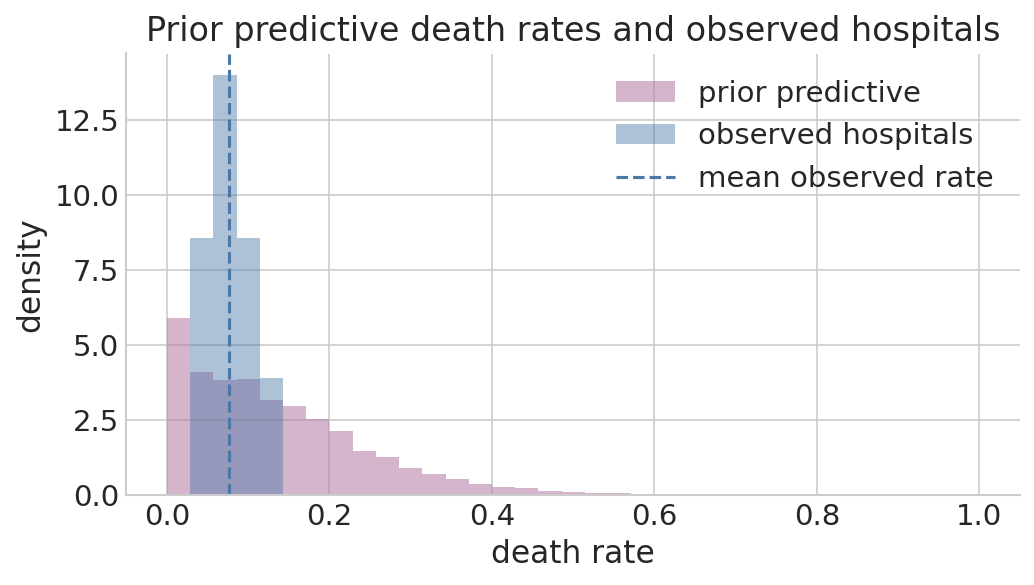

In [173]:
with hospital_beta_binomial_model:
    idata_hospital_prior = pm.sample_prior_predictive(
        samples=1000,
        random_seed=123,
    )

prior_z = az.extract(idata_hospital_prior, group="prior_predictive", var_names="z")
prior_death_rate = prior_z / cases[:, None]

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, max(0.35, prior_death_rate.max().item(), observed_rate.max()), 36)

ax.hist(prior_death_rate.values.ravel(), bins=bins, density=True, color=HIERARCHICAL_COLOR, alpha=0.55, label="prior predictive")
ax.hist(observed_rate, bins=bins, density=True, color=HOSPITAL_COLOR, alpha=0.45, label="observed hospitals")
ax.axvline(observed_rate.mean(), color=HOSPITAL_COLOR, linestyle="--", label="mean observed rate")
ax.set(xlabel="death rate", ylabel="density", title="Prior predictive death rates and observed hospitals")
ax.legend()

fig.tight_layout()


<a id="section-57"></a>
## 5.7 Fitting and checking the hierarchical model

Before interpreting the hierarchy, check sampling diagnostics, trace plots, pair plots, and posterior predictive fit.


In [174]:
with hospital_beta_binomial_model:
    idata_hospital = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=123,
        progressbar=False,
    )

hospital_parameter_summary = az.summary(
    idata_hospital,
    var_names=["mu_theta", "nu_theta"],
    hdi_prob=0.94,
)
selected_theta_summary = az.summary(
    idata_hospital,
    var_names=["theta"],
    coords={"data": selected_hospitals},
    hdi_prob=0.94,
)

pd.concat([hospital_parameter_summary, selected_theta_summary])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_theta, nu_theta, theta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 29 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_theta,0.078,0.005,0.069,0.087,0.0,0.000,3602.0,2840.0,1.0
nu_theta,118.077,27.888,67.031,171.123,0.5,0.398,3119.0,3088.0,1.0
theta[Bellevue Center],0.053,0.014,0.028,0.080,0.0,0.000,4717.0,3091.0,1.0
theta[Lenox Hill],0.079,0.015,0.051,0.106,0.0,0.000,5121.0,2275.0,1.0
theta[Harlem Center],0.067,0.020,0.030,0.103,0.0,0.000,5846.0,3192.0,1.0
theta[Forest Hills],0.106,0.018,0.074,0.140,0.0,0.000,5524.0,3018.0,1.0
theta[Metropolitan Center],0.080,0.020,0.044,0.117,0.0,0.000,5669.0,3190.0,1.0


C:\Users\User\AppData\Local\Temp\ipykernel_17968\3333686078.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


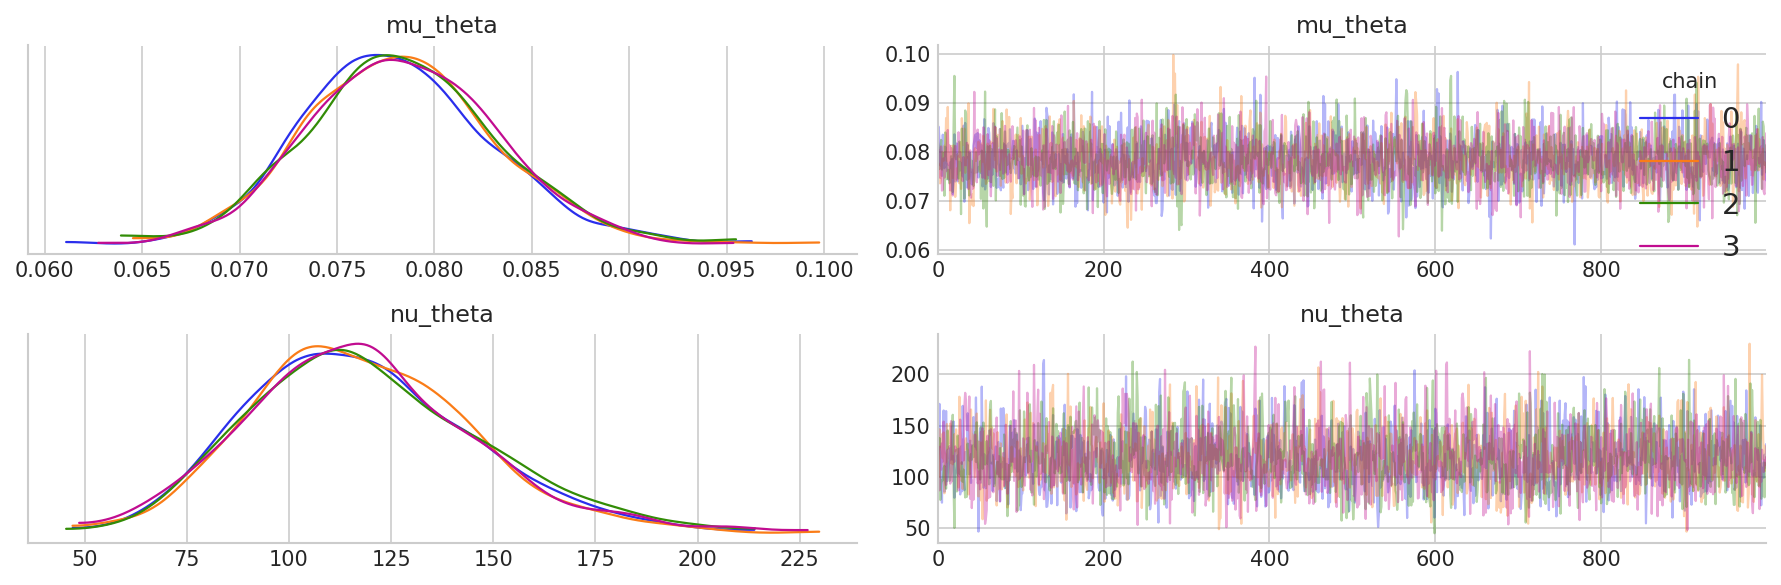

In [175]:
az.plot_trace(
    idata_hospital,
    var_names=["mu_theta", "nu_theta"],
    compact=False,
    chain_prop="color",
    legend=True,
)
plt.tight_layout()


C:\Users\User\AppData\Local\Temp\ipykernel_17968\1079706816.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


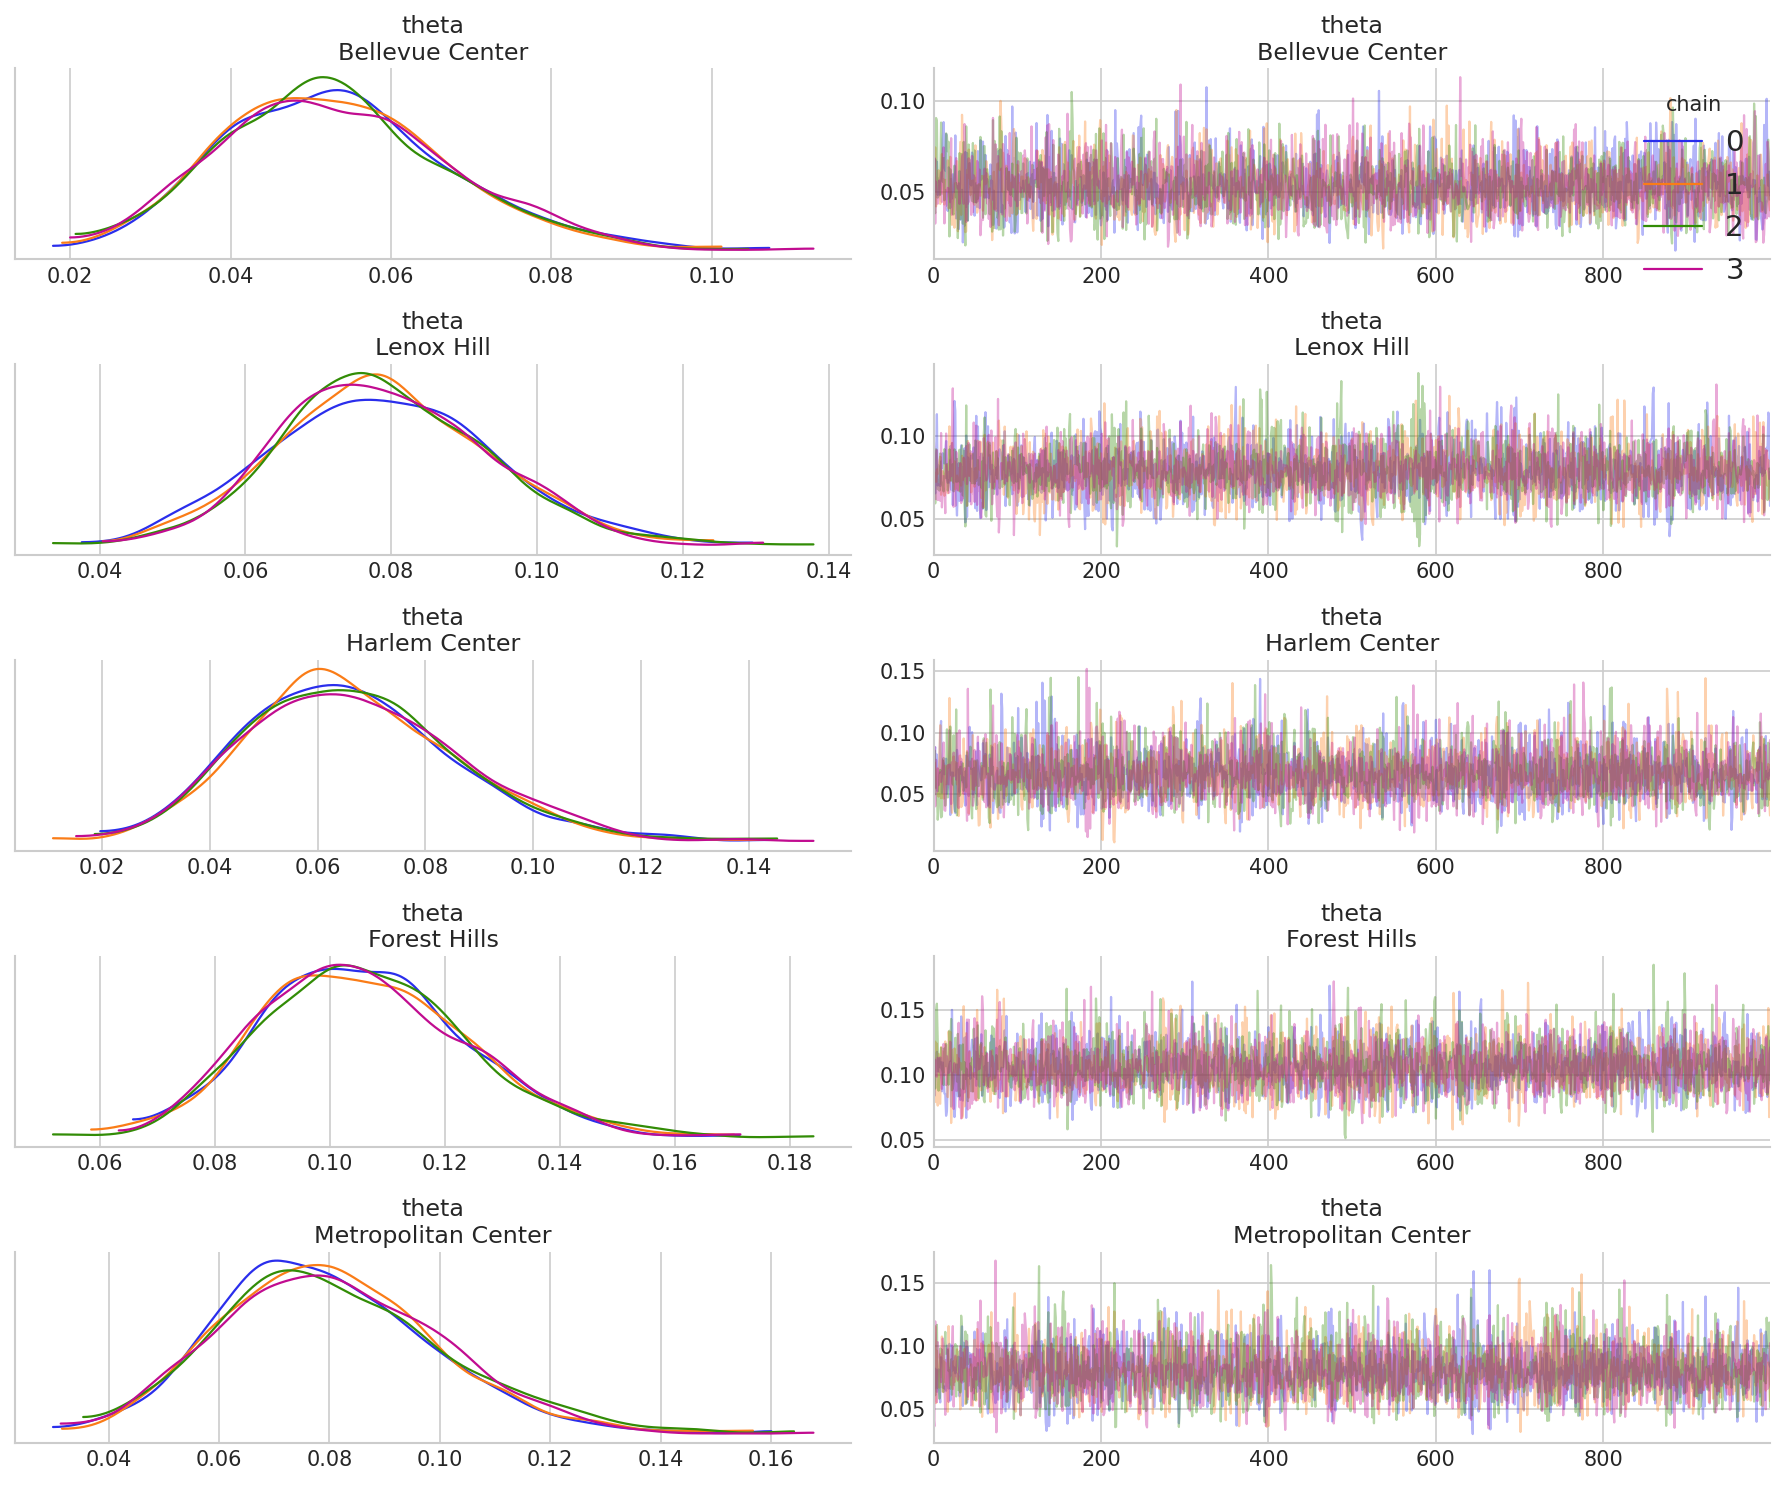

In [176]:
az.plot_trace(
    idata_hospital,
    var_names=["theta"],
    coords={"data": selected_hospitals},
    compact=False,
    chain_prop="color",
    legend=True,
)
plt.tight_layout()


C:\Users\User\AppData\Local\Temp\ipykernel_17968\3483939212.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


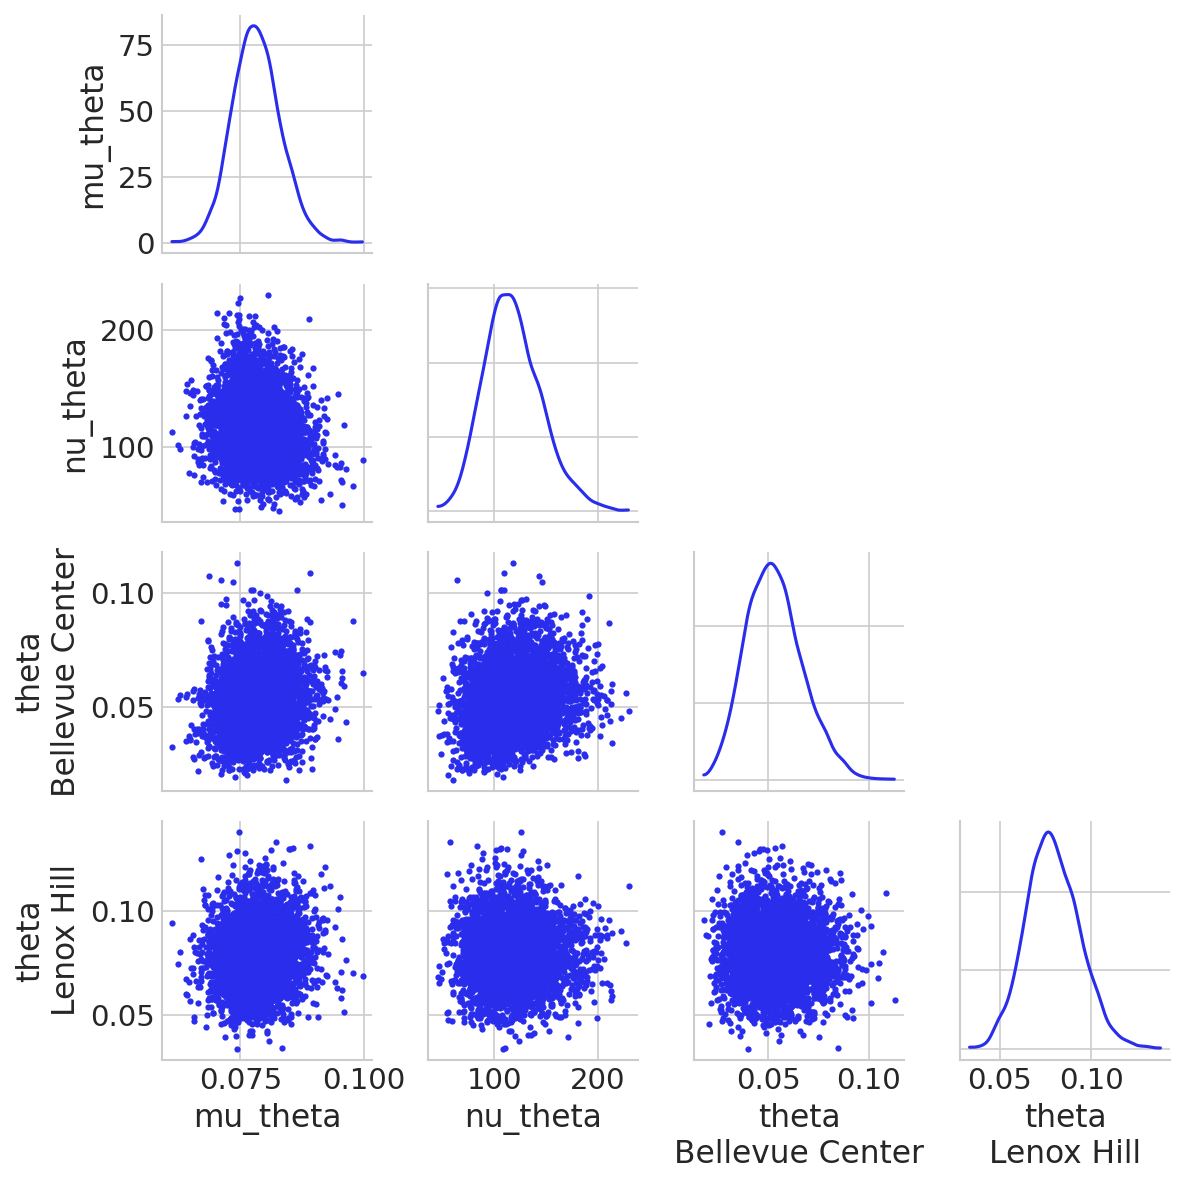

In [177]:
az.plot_pair(
    idata_hospital,
    var_names=["mu_theta", "nu_theta", "theta"],
    coords={"data": selected_hospitals[:2]},
    kind="scatter",
    marginals=True,
    figsize=(8, 8),
)
plt.tight_layout()


Sampling: [z]
Sampling: [theta, z]
C:\Users\User\AppData\Local\Temp\ipykernel_17968\1698937605.py:52: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_17968\1698937605.py:60: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


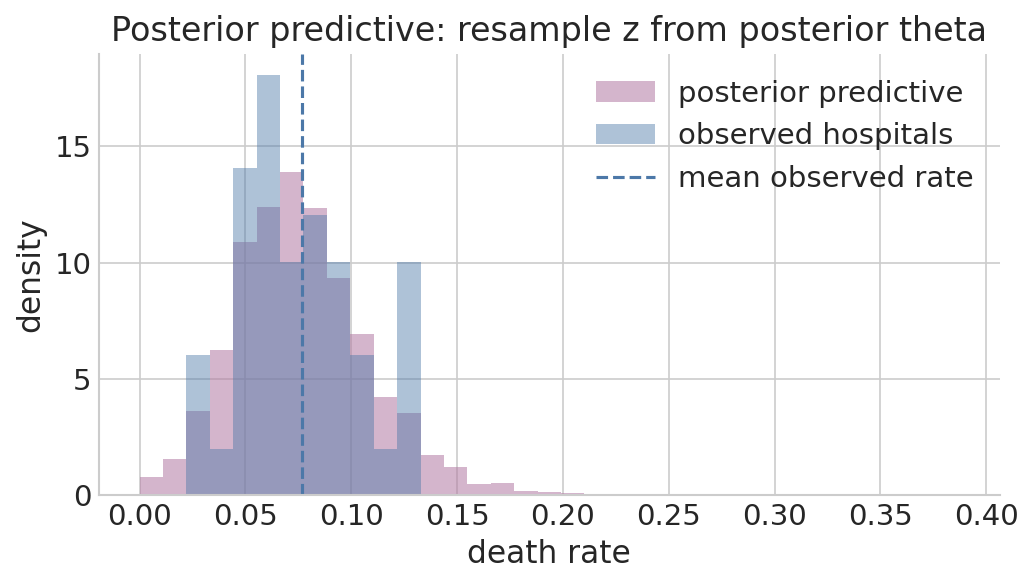

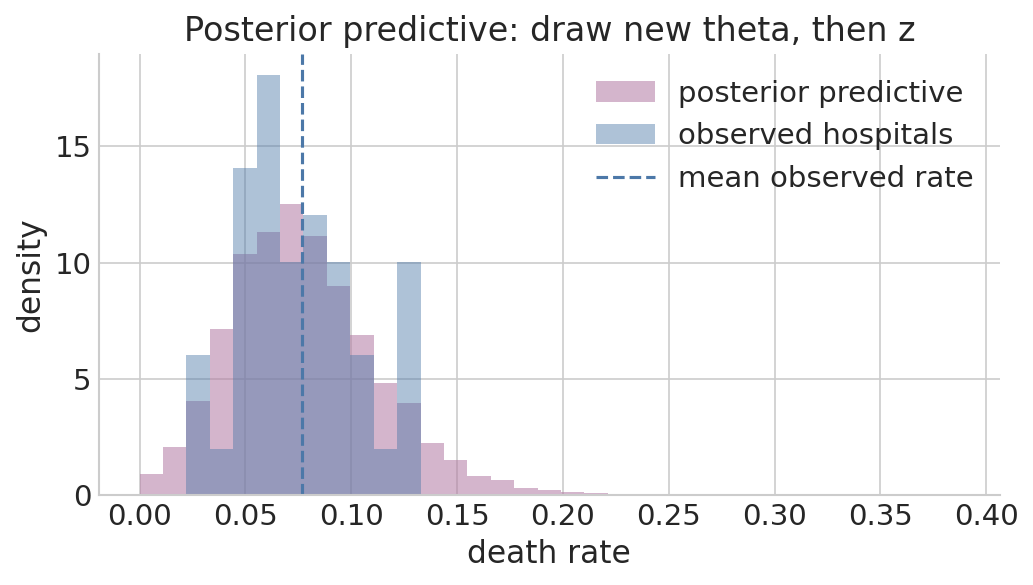

In [178]:
with hospital_beta_binomial_model:
    try:
        idata_hospital_posterior = pm.sample_posterior_predictive(
            idata_hospital,
            var_names=["z"],
            freeze_vars=["theta", "mu_theta", "nu_theta"],
            random_seed=124,
            progressbar=False,
        )
    except TypeError:
        idata_hospital_posterior = pm.sample_posterior_predictive(
            idata_hospital,
            var_names=["z"],
            random_seed=124,
            progressbar=False,
        )

    try:
        idata_hospital_posterior_new_theta = pm.sample_posterior_predictive(
            idata_hospital,
            var_names=["z"],
            sample_vars=["theta"],
            freeze_vars=["mu_theta", "nu_theta"],
            random_seed=126,
            progressbar=False,
        )
    except TypeError:
        idata_hospital_posterior_new_theta = pm.sample_posterior_predictive(
            idata_hospital,
            var_names=["theta", "z"],
            random_seed=126,
            progressbar=False,
        )

posterior_z = az.extract(idata_hospital_posterior, group="posterior_predictive", var_names="z")
posterior_death_rate = posterior_z / cases[:, None]
new_theta_z = az.extract(idata_hospital_posterior_new_theta, group="posterior_predictive", var_names="z")
new_theta_death_rate = new_theta_z / cases[:, None]

bins = np.linspace(
    0,
    max(0.35, posterior_death_rate.max().item(), new_theta_death_rate.max().item(), observed_rate.max()),
    36,
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(posterior_death_rate.values.ravel(), bins=bins, density=True, color=HIERARCHICAL_COLOR, alpha=0.55, label="posterior predictive")
ax.hist(observed_rate, bins=bins, density=True, color=HOSPITAL_COLOR, alpha=0.45, label="observed hospitals")
ax.axvline(observed_rate.mean(), color=HOSPITAL_COLOR, linestyle="--", label="mean observed rate")
ax.set(xlabel="death rate", ylabel="density", title="Posterior predictive: resample z from posterior theta")
ax.legend()
fig.tight_layout()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(new_theta_death_rate.values.ravel(), bins=bins, density=True, color=HIERARCHICAL_COLOR, alpha=0.55, label="posterior predictive")
ax.hist(observed_rate, bins=bins, density=True, color=HOSPITAL_COLOR, alpha=0.45, label="observed hospitals")
ax.axvline(observed_rate.mean(), color=HOSPITAL_COLOR, linestyle="--", label="mean observed rate")
ax.set(xlabel="death rate", ylabel="density", title="Posterior predictive: draw new theta, then z")
ax.legend()
fig.tight_layout()


<a id="section-58"></a>
## 5.8 Posterior interpretation: shrinkage and uncertainty

After prior predictive checks, diagnostics, and posterior predictive checks, it is safe to interpret the posterior. Partial pooling changes both the hospital estimates and their uncertainty.


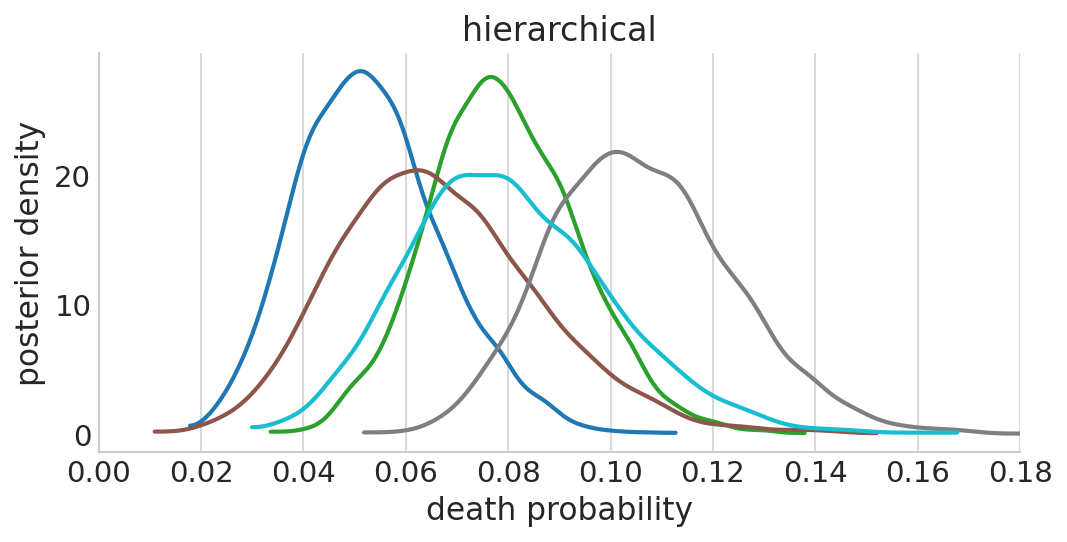

In [179]:
fig, ax = plt.subplots(figsize=(7, 3.5))
theta_hierarchical_samples = az.extract(idata_hospital, var_names="theta")

for hospital in selected_hospitals:
    hospital_samples = theta_hierarchical_samples.sel(data=hospital).to_numpy()
    az.plot_kde(
        hospital_samples,
        ax=ax,
        plot_kwargs={"color": selected_hospital_colors[hospital], "linewidth": 2, "label": hospital},
    )

ax.set(title="hierarchical", xlabel="death probability", ylabel="posterior density")
ax.set_xlim(0, 0.18)
ax.grid(axis="x", color="0.85", linewidth=1)
ax.grid(axis="y", visible=False)
legend = ax.get_legend()
if legend is not None:
    legend.remove()


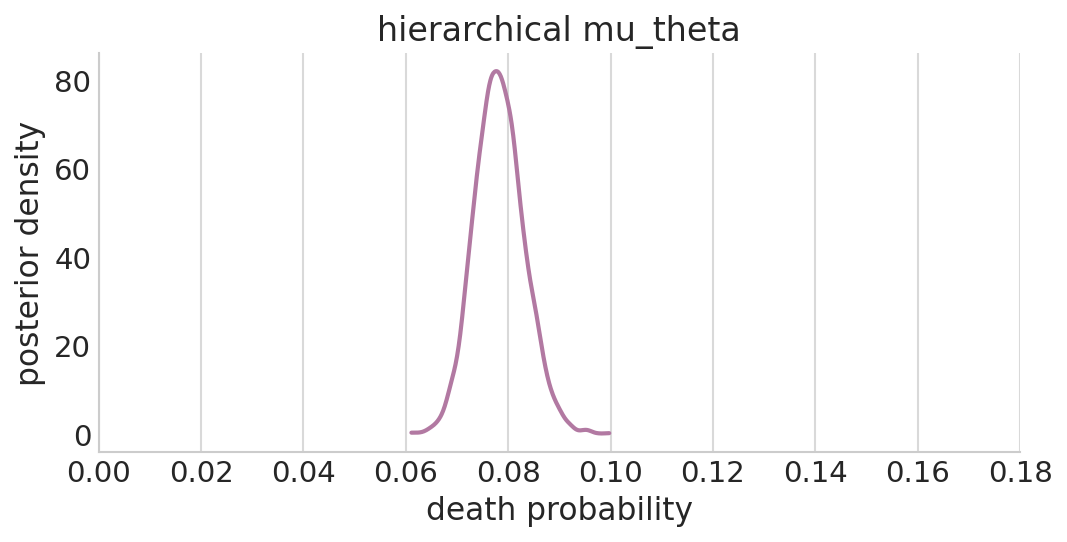

In [180]:
fig, ax = plt.subplots(figsize=(7, 3.5))
mu_theta_samples = az.extract(idata_hospital, var_names="mu_theta").to_numpy()
az.plot_kde(
    mu_theta_samples,
    ax=ax,
    plot_kwargs={"color": HIERARCHICAL_COLOR, "linewidth": 2},
)
ax.set(title="hierarchical mu_theta", xlabel="death probability", ylabel="posterior density")
ax.set_xlim(0, 0.18)
ax.grid(axis="x", color="0.85", linewidth=1)
ax.grid(axis="y", visible=False)


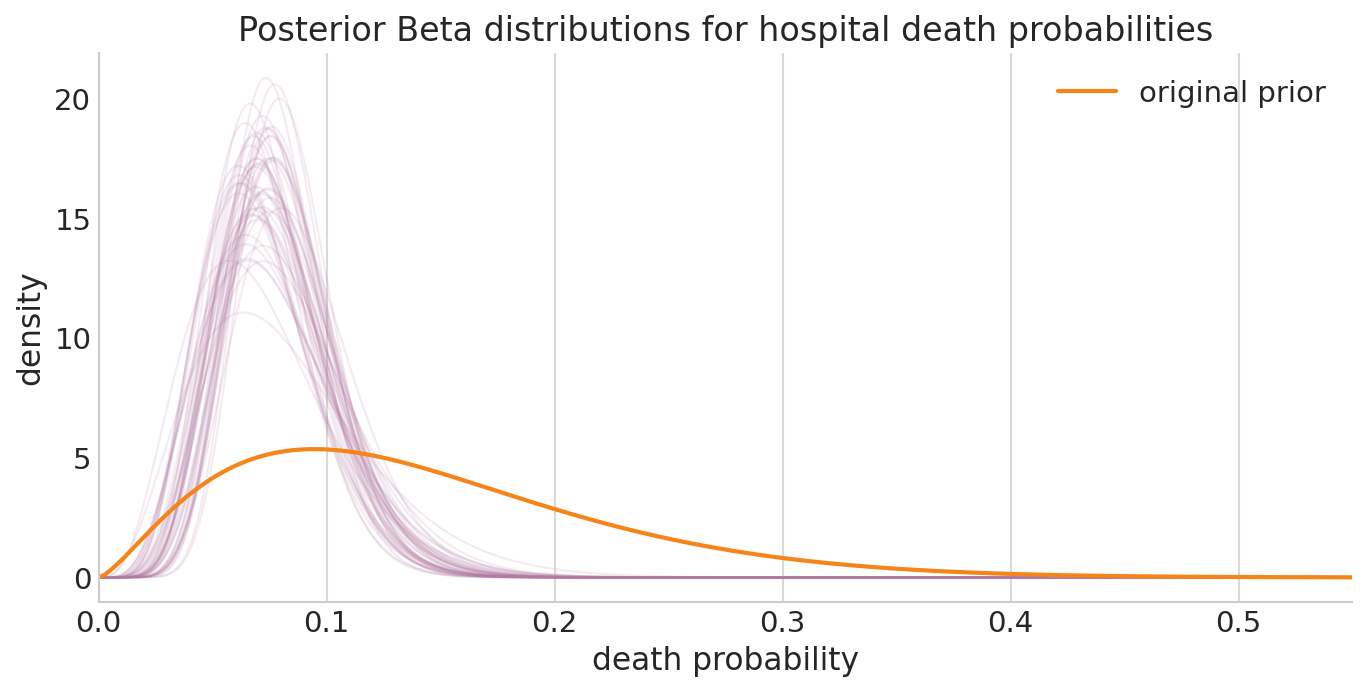

In [181]:
posterior_hyper = az.extract(
    idata_hospital,
    var_names=["mu_theta", "nu_theta"],
    num_samples=50,
    rng=rng,
    keep_dataset=True,
)
theta_grid_wide = np.linspace(0.001, 0.55, 400)

fig, ax = plt.subplots(figsize=(9, 4.5))
for mu_sample, nu_sample in zip(posterior_hyper["mu_theta"].to_numpy(), posterior_hyper["nu_theta"].to_numpy()):
    alpha_sample = mu_sample * nu_sample
    beta_sample = (1 - mu_sample) * nu_sample
    ax.plot(
        theta_grid_wide,
        stats.beta(alpha_sample, beta_sample).pdf(theta_grid_wide),
        color=HIERARCHICAL_COLOR,
        alpha=0.15,
        linewidth=1,
    )

ax.plot(
    theta_grid_wide,
    stats.beta(omega_alpha, omega_beta).pdf(theta_grid_wide),
    color=POOLED_COLOR,
    linewidth=2,
    label="original prior",
)
ax.set(
    title="Posterior Beta distributions for hospital death probabilities",
    xlabel="death probability",
    ylabel="density",
    xlim=(0, 0.55),
)
ax.grid(axis="x", color="0.85", linewidth=1)
ax.grid(axis="y", visible=False)
ax.legend()


In [182]:
theta_posterior = idata_hospital.posterior["theta"]
theta_hdi = az.hdi(theta_posterior, hdi_prob=0.94).theta.to_numpy()
theta_mean = theta_posterior.mean(("chain", "draw")).to_numpy()

hierarchical_summary = death_data.assign(
    hierarchical_mean=theta_mean,
    hierarchical_lower=theta_hdi[:, 0],
    hierarchical_upper=theta_hdi[:, 1],
)


In [183]:
shrinkage_summary = hierarchical_summary.assign(
    movement=hierarchical_summary["hierarchical_mean"] - hierarchical_summary["DeathRate"],
    absolute_movement=lambda df: df["movement"].abs(),
)


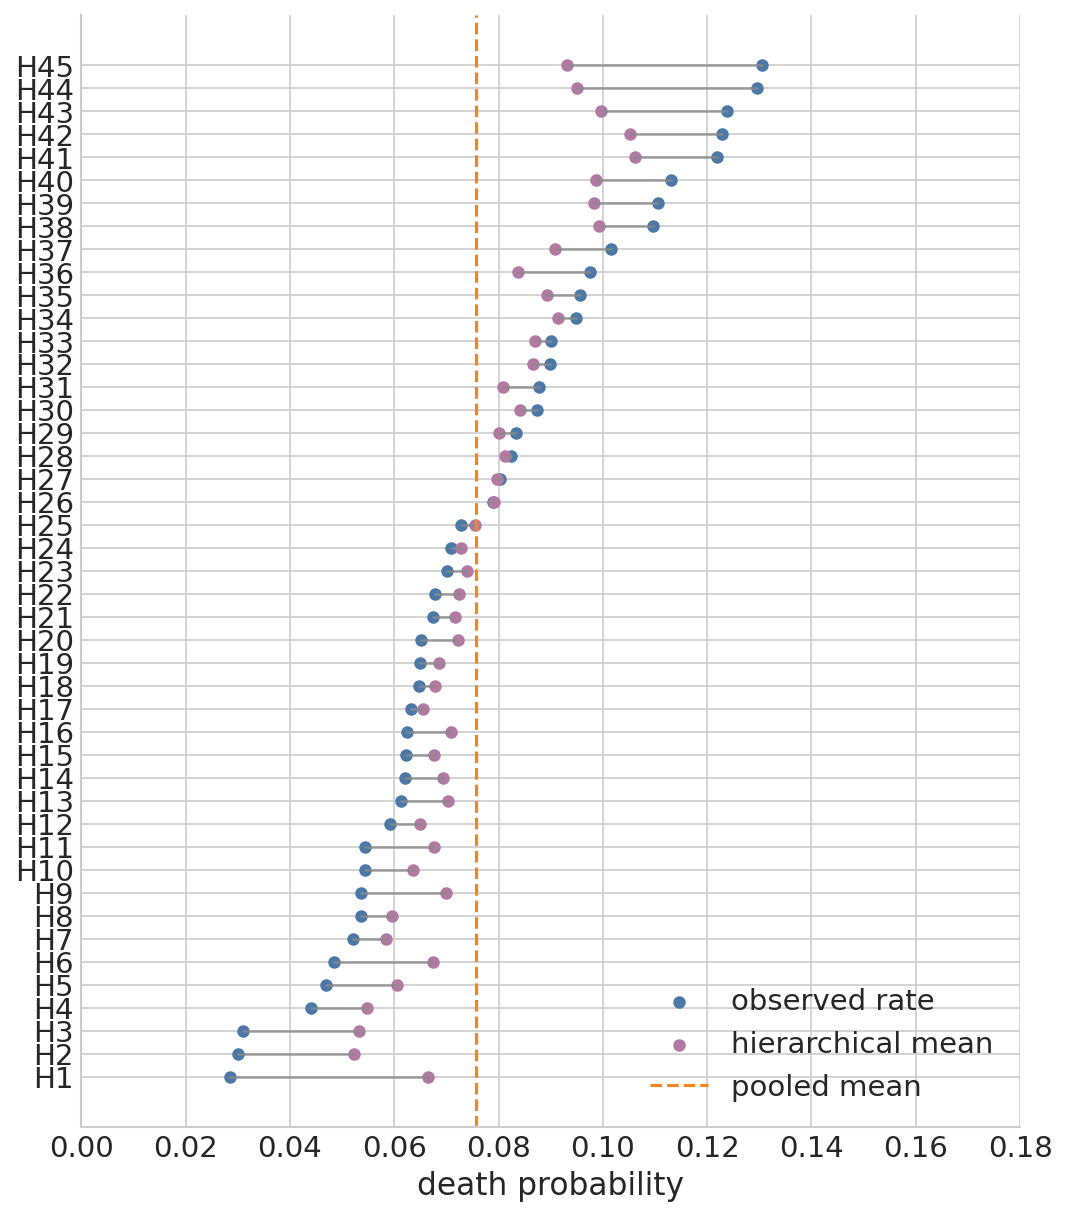

In [184]:
shrinkage_y_pos = np.arange(len(hierarchical_summary))

fig, ax = plt.subplots(figsize=(7, 8))
for pos in shrinkage_y_pos:
    ax.plot(
        [observed_rate[pos], theta_mean[pos]],
        [pos, pos],
        color=INTERVAL_COLOR,
        linewidth=1.2,
        alpha=0.8,
    )
ax.scatter(observed_rate, shrinkage_y_pos, color=HOSPITAL_COLOR, s=25, label="observed rate")
ax.scatter(theta_mean, shrinkage_y_pos, color=HIERARCHICAL_COLOR, s=25, label="hierarchical mean")
ax.axvline(pooled_posterior_mean, color=POOLED_COLOR, linestyle="--", label="pooled mean")
ax.set(yticks=shrinkage_y_pos, yticklabels=hospital_labels, xlabel="death probability", xlim=(0, 0.18))
ax.legend(loc="lower right")


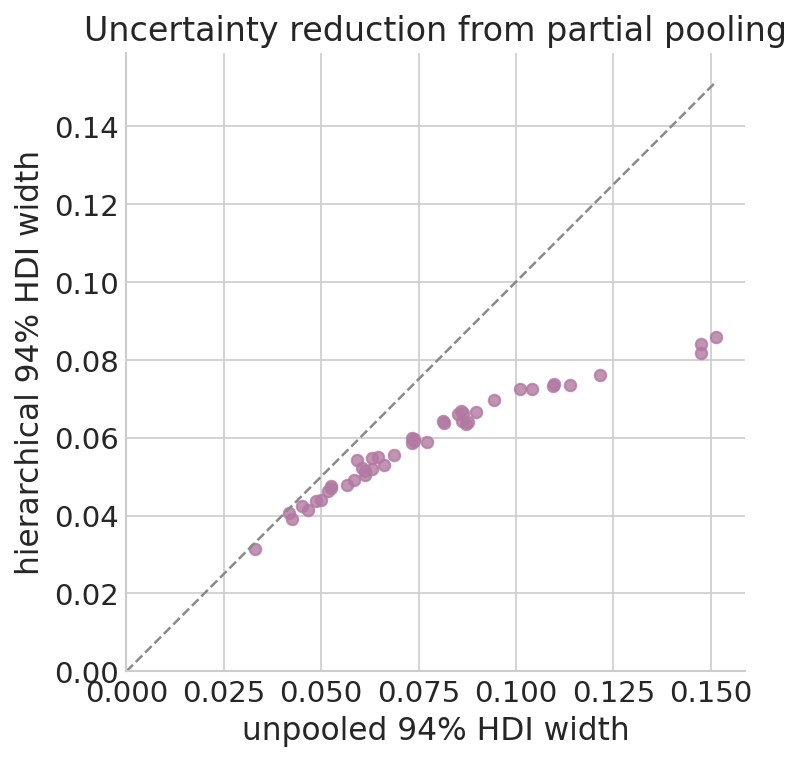

In [185]:
unpooled_hdi_width = separate_interval[:, 1] - separate_interval[:, 0]
hierarchical_hdi_width = theta_hdi[:, 1] - theta_hdi[:, 0]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(unpooled_hdi_width, hierarchical_hdi_width, color=HIERARCHICAL_COLOR, s=30, alpha=0.8)
max_width = max(unpooled_hdi_width.max(), hierarchical_hdi_width.max())
ax.plot([0, max_width], [0, max_width], color=INTERVAL_COLOR, linestyle="--", linewidth=1.2)
ax.set(
    xlabel="unpooled 94% HDI width",
    ylabel="hierarchical 94% HDI width",
    title="Uncertainty reduction from partial pooling",
    xlim=(0, max_width * 1.05),
    ylim=(0, max_width * 1.05),
)
ax.set_aspect("equal", adjustable="box")


The posterior for each `theta` is the partially pooled estimate of that hospital's death probability.

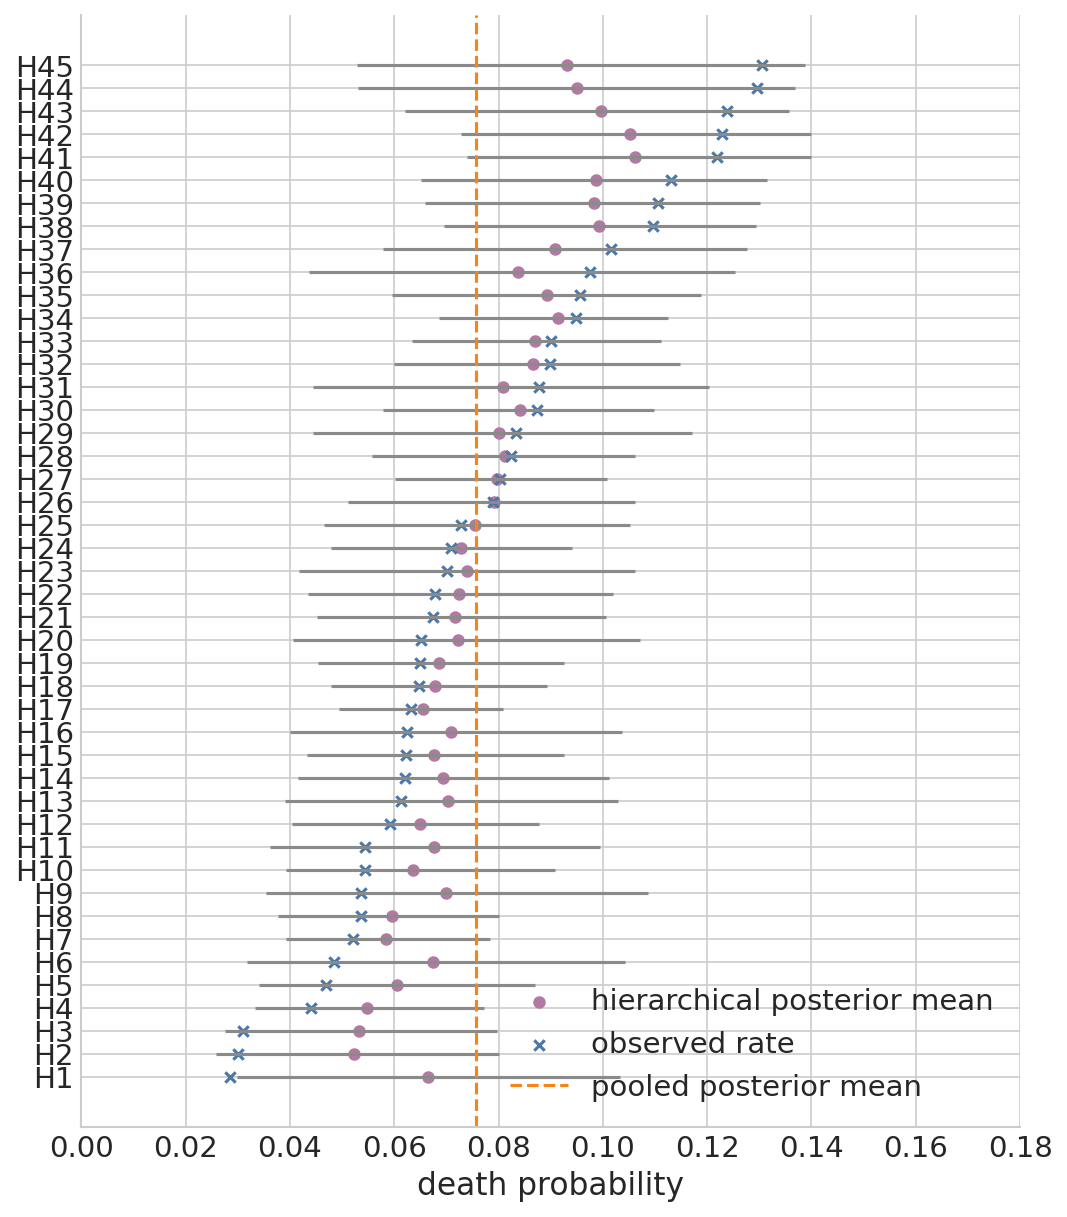

In [186]:
interval_y_pos = np.arange(len(hierarchical_summary))

fig, ax = plt.subplots(figsize=(7, 8))
ax.hlines(interval_y_pos, theta_hdi[:, 0], theta_hdi[:, 1], color=INTERVAL_COLOR, linewidth=1.5)
ax.scatter(theta_mean, interval_y_pos, color=HIERARCHICAL_COLOR, s=25, label="hierarchical posterior mean")
ax.scatter(observed_rate, interval_y_pos, color=HOSPITAL_COLOR, marker="x", s=25, label="observed rate")
ax.axvline(pooled_posterior_mean, color=POOLED_COLOR, linestyle="--", label="pooled posterior mean")
ax.set(yticks=interval_y_pos, yticklabels=hospital_labels, xlabel="death probability", xlim=(0, 0.18))
ax.legend(loc="lower right")


The chapter highlights a useful rank reversal in the Manhattan subset: Mount Sinai Roosevelt has a higher raw rate than NYP Allen, but it also has far fewer cases.

In [187]:
highlight_names = [
    "Mount Sinai Roosevelt",
    "New York Presbyterian Hospital - Allen Hospital",
]
highlight = hierarchical_summary[hierarchical_summary["Hospital"].isin(highlight_names)]
highlight[["Hospital", "Cases", "Deaths", "DeathRate", "hierarchical_mean", "hierarchical_lower", "hierarchical_upper"]]


,Hospital,Cases,Deaths,DeathRate,hierarchical_mean,hierarchical_lower,hierarchical_upper
42,New York Presbyterian Hospital - Allen Hospital,105,13,0.123810,0.099703,0.062136,0.135772
44,Mount Sinai Roosevelt,46,6,0.130435,0.093205,0.052879,0.138752


In [188]:
theta_samples = az.extract(idata_hospital, var_names="theta")
roosevelt_label = death_data.loc[
    death_data["Hospital"].eq("Mount Sinai Roosevelt"),
    "HospitalShort",
].item()
allen_label = death_data.loc[
    death_data["Hospital"].eq("New York Presbyterian Hospital - Allen Hospital"),
    "HospitalShort",
].item()

roosevelt = theta_samples.sel(data=roosevelt_label)
allen = theta_samples.sel(data=allen_label)

prob_allen_higher = float((allen > roosevelt).mean())
prob_allen_higher


0.5885

Posterior comparisons use the full posterior draws, not just point estimates.

In [189]:
rank_samples = theta_samples.to_numpy().T.argsort(axis=1)
best_hospital_indices = rank_samples[:, 0]
best_probability = pd.Series(best_hospital_indices).value_counts(normalize=True).sort_index()

rank_summary = pd.DataFrame({
    "Hospital": hospital_names,
    "Pr_best_lowest_death_rate": [best_probability.get(idx, 0.0) for idx in range(len(hospital_names))],
    "hierarchical_mean": theta_mean,
    "observed_rate": observed_rate,
})
rank_summary.sort_values("Pr_best_lowest_death_rate", ascending=False).head(10)


,Hospital,Pr_best_lowest_death_rate,hierarchical_mean,observed_rate
1,Lincoln Medical & Mental Health Center,0.18275,0.052344,0.030075
2,Bellevue Center,0.17025,0.053155,0.031008
3,New York Presbyterian - New York Weill Cornell...,0.09500,0.054731,0.044000
4,Wyckoff Heights MC,0.06850,0.060587,0.046980
0,Harlem Center,0.06200,0.066544,0.028571
5,Montefiore MC - Wakefield,0.05175,0.067522,0.048387
8,Flushing MC,0.04075,0.069870,0.053571
7,Montefiore Med Center - Jack D Weiler of A Ein...,0.03700,0.059599,0.053571
6,Long Island Jewish MC,0.03650,0.058454,0.052055
9,Queens Center,0.03025,0.063597,0.054348


<a id="section-59"></a>
## 5.9 Benefits and pitfalls

Hierarchical models better match grouped data and stabilize noisy group estimates. The tradeoff is workflow burden: hyperpriors matter, diagnostics matter, and posterior predictive checks need to be interpreted at the right level of the hierarchy.


<a id="section-511"></a>
## 5.10 Funnel and non-centering

Hierarchical models can be harder to sample because population parameters and group parameters constrain each other. The same likelihood can have very different sampling geometry under different parameterizations.


In [244]:
small_hospital_data = death_data.nsmallest(8, "Cases").reset_index(drop=True)
small_hospital_names = small_hospital_data["HospitalShort"].to_numpy()
small_cases = small_hospital_data["Cases"].to_numpy()
small_deaths = small_hospital_data["Deaths"].to_numpy()

small_hospital_data[["Hospital", "Type", "Cases", "Deaths", "DeathRate"]]


,Hospital,Type,Cases,Deaths,DeathRate
0,Harlem Hospital Center,Non-PCI,35,1,0.028571
1,New York-Presbyterian/Lower Manhattan Hospital,Non-PCI,41,4,0.097561
2,Mount Sinai Roosevelt,Non-PCI,46,6,0.130435
3,Staten Island University Hospital - South,Non-PCI,54,7,0.129630
4,Flushing Hospital Medical Center,Non-PCI,56,3,0.053571
5,St Johns Episcopal Hospital So Shore,Non-PCI,57,5,0.087719
6,Montefiore Medical Center - Wakefield Hospital,Non-PCI,62,3,0.048387
7,Metropolitan Hospital Center,Non-PCI,84,7,0.083333


First fit the `nu_theta` parameterization to the full data and to the weak subset. The model is the same; only the amount of information changes.

In [245]:
coords_funnel_full = {"data": hospital_names}

with pm.Model(coords=coords_funnel_full) as full_nu_model:
    mu_theta = pm.Beta("mu_theta", mu=omega_mu, nu=omega_nu)
    nu_theta = pm.HalfNormal("nu_theta", sigma=200)
    theta = pm.Beta("theta", mu=mu_theta, nu=nu_theta, dims="data")
    z = pm.Binomial("z", n=cases, p=theta, observed=deaths, dims="data")

    idata_full_nu = pm.sample(
        draws=500,
        tune=500,
        chains=4,
        target_accept=0.8,
        random_seed=789,
        progressbar=False,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_theta, nu_theta, theta]
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 49 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [246]:
coords_funnel_small = {"data": small_hospital_names}

with pm.Model(coords=coords_funnel_small) as small_nu_model:
    mu_theta = pm.Beta("mu_theta", mu=omega_mu, nu=omega_nu)
    nu_theta = pm.HalfNormal("nu_theta", sigma=200)
    theta = pm.Beta("theta", mu=mu_theta, nu=nu_theta, dims="data")
    z = pm.Binomial("z", n=small_cases, p=theta, observed=small_deaths, dims="data")

    idata_small_nu = pm.sample(
        draws=500,
        tune=500,
        chains=4,
        target_accept=0.8,
        random_seed=790,
        progressbar=False,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_theta, nu_theta, theta]
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 20 seconds.


Now fit a width parameterization. Because the Beta standard deviation must be less than `sqrt(mu_theta * (1 - mu_theta))`, we sample a proportion of that maximum width and then compute `sigma_theta` deterministically.

In [247]:
with pm.Model(coords=coords_funnel_full) as full_sigma_model:
    mu_theta = pm.Beta("mu_theta", mu=omega_mu, nu=omega_nu)
    rho_sigma_theta = pm.Beta("rho_sigma_theta", alpha=2, beta=2)
    sigma_theta = pm.Deterministic(
        "sigma_theta",
        0.99 * rho_sigma_theta * pm.math.sqrt(mu_theta * (1 - mu_theta)),
    )
    theta = pm.Beta("theta", mu=mu_theta, sigma=sigma_theta, dims="data")
    z = pm.Binomial("z", n=cases, p=theta, observed=deaths, dims="data")

    idata_full_sigma = pm.sample(
        draws=500,
        tune=500,
        chains=4,
        target_accept=0.8,
        random_seed=791,
        progressbar=False,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_theta, rho_sigma_theta, theta]
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 23 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [248]:
with pm.Model(coords=coords_funnel_small) as small_sigma_model:
    mu_theta = pm.Beta("mu_theta", mu=omega_mu, nu=omega_nu)
    rho_sigma_theta = pm.Beta("rho_sigma_theta", alpha=2, beta=2)
    sigma_theta = pm.Deterministic(
        "sigma_theta",
        0.99 * rho_sigma_theta * pm.math.sqrt(mu_theta * (1 - mu_theta)),
    )
    theta = pm.Beta("theta", mu=mu_theta, sigma=sigma_theta, dims="data")
    z = pm.Binomial("z", n=small_cases, p=theta, observed=small_deaths, dims="data")

    idata_small_sigma = pm.sample(
        draws=500,
        tune=500,
        chains=4,
        target_accept=0.8,
        random_seed=792,
        progressbar=False,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_theta, rho_sigma_theta, theta]
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 26 seconds.
There were 19 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Diagnostics show whether the geometry is merely visible or actually harmful for sampling.

In [249]:
def divergence_count(idata):
    return int(idata.sample_stats["diverging"].sum())


def max_tree_depth_count(idata):
    return int(idata.sample_stats["reached_max_treedepth"].sum())


def diagnostic_row(label, idata, var_names):
    summary = az.summary(idata, var_names=var_names)
    return {
        "model": label,
        "divergences": divergence_count(idata),
        "max_tree_depth_hits": max_tree_depth_count(idata),
        "min_ess_bulk": summary["ess_bulk"].min(),
        "max_r_hat": summary["r_hat"].max(),
    }


funnel_diagnostics = pd.DataFrame([
    diagnostic_row("full data, nu_theta", idata_full_nu, ["mu_theta", "nu_theta"]),
    diagnostic_row("weak subset, nu_theta", idata_small_nu, ["mu_theta", "nu_theta"]),
    diagnostic_row("full data, sigma_theta", idata_full_sigma, ["mu_theta", "sigma_theta"]),
    diagnostic_row("weak subset, sigma_theta", idata_small_sigma, ["mu_theta", "sigma_theta"]),
])
funnel_diagnostics


,model,divergences,max_tree_depth_hits,min_ess_bulk,max_r_hat
0,"full data, nu_theta",0,0,512.0,1.02
1,"weak subset, nu_theta",0,0,638.0,1.01
2,"full data, sigma_theta",0,0,192.0,1.01
3,"weak subset, sigma_theta",19,0,139.0,1.03


The geometry plot uses the average distance between each hospital `theta` and the shared `mu_theta`. A narrow neck means the group probabilities are forced close to the shared mean.

In [252]:
def posterior_distance(idata, parameter_name=None):
    var_names = ["theta", "mu_theta"]
    if parameter_name is not None and parameter_name not in var_names:
        var_names.append(parameter_name)

    posterior = az.extract(idata, var_names=var_names, keep_dataset=True)
    distance = np.abs(posterior["theta"] - posterior["mu_theta"]).mean("data")
    diverging = az.extract(idata, group="sample_stats", var_names="diverging").to_numpy().astype(bool)
    return posterior, distance, diverging


def shared_geometry_limits(idatas, parameter_name):
    parameter_values = []
    distance_values = []
    for idata in idatas:
        posterior, distance, _ = posterior_distance(idata, parameter_name)
        parameter_values.append(posterior[parameter_name].to_numpy())
        distance_values.append(distance.to_numpy())

    x_values = np.concatenate(parameter_values)
    y_values = np.concatenate(distance_values)
    x_margin = 0.05 * (x_values.max() - x_values.min())
    y_margin = 0.05 * (y_values.max() - y_values.min())
    return (
        (max(0, x_values.min() - x_margin), x_values.max() + x_margin),
        (max(0, y_values.min() - y_margin), y_values.max() + y_margin),
    )


def plot_geometry(idata, parameter_name, n_hospitals, xlim, ylim):
    posterior, distance, diverging = posterior_distance(idata, parameter_name)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(
        posterior[parameter_name].to_numpy()[~diverging],
        distance.to_numpy()[~diverging],
        s=8,
        alpha=0.25,
        color=HOSPITAL_COLOR,
        label="non-divergent draws",
    )
    if diverging.any():
        ax.scatter(
            posterior[parameter_name].to_numpy()[diverging],
            distance.to_numpy()[diverging],
            s=16,
            alpha=0.8,
            color=NONPCI_COLOR,
            label="divergent draws",
        )
    ax.set(
        title=f"Number of hospitals: {n_hospitals}",
        xlabel=parameter_name,
        ylabel="average |theta - mu_theta|",
        xlim=xlim,
        ylim=ylim,
    )
    ax.legend(loc="upper right")
    return fig, ax


nu_xlim, nu_ylim = shared_geometry_limits([idata_full_nu, idata_small_nu], "nu_theta")
sigma_xlim, sigma_ylim = shared_geometry_limits([idata_full_sigma, idata_small_sigma], "sigma_theta")


(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Number of hospitals: 45'}, xlabel='nu_theta', ylabel='average |theta - mu_theta|'>)

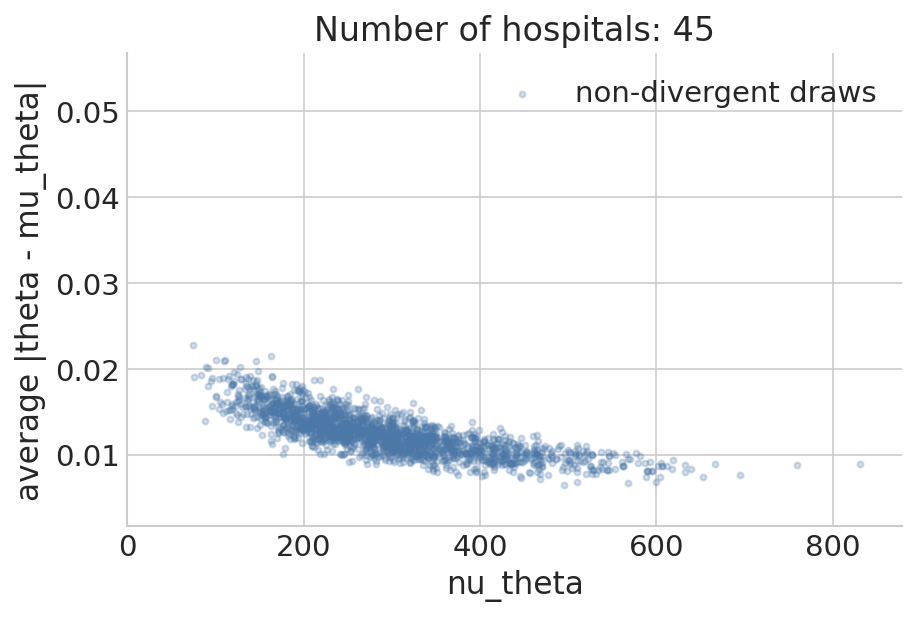

In [253]:
plot_geometry(
    idata_full_nu,
    parameter_name="nu_theta",
    n_hospitals=len(hospital_names),
    xlim=nu_xlim,
    ylim=nu_ylim,
)


(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Number of hospitals: 8'}, xlabel='nu_theta', ylabel='average |theta - mu_theta|'>)

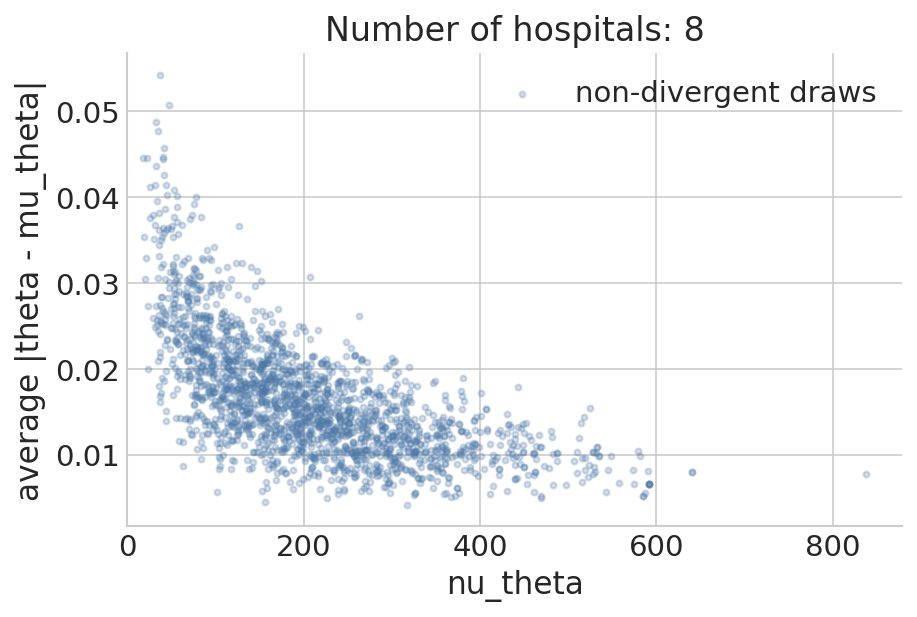

In [254]:
plot_geometry(
    idata_small_nu,
    parameter_name="nu_theta",
    n_hospitals=len(small_hospital_names),
    xlim=nu_xlim,
    ylim=nu_ylim,
)


(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Number of hospitals: 45'}, xlabel='sigma_theta', ylabel='average |theta - mu_theta|'>)

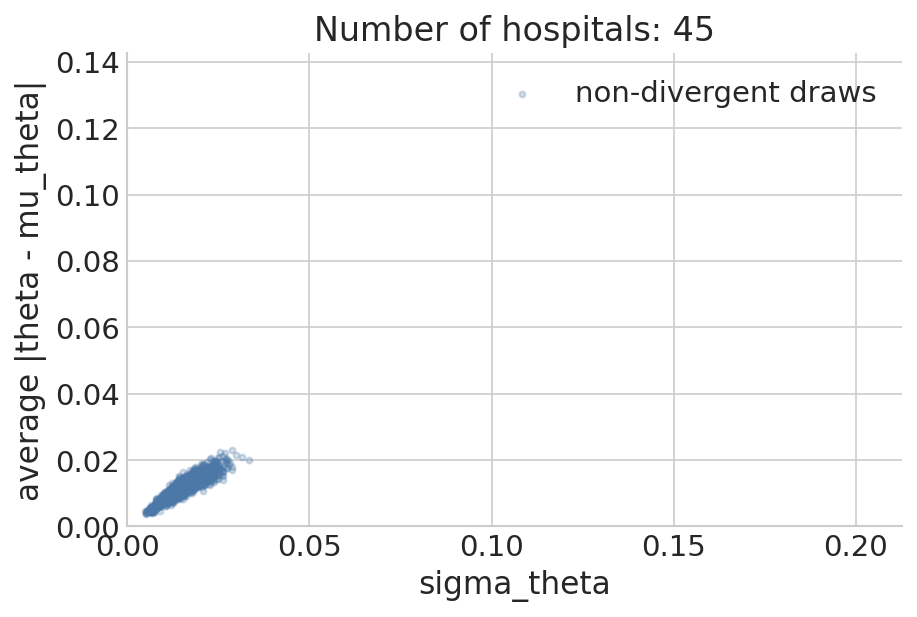

In [255]:
plot_geometry(
    idata_full_sigma,
    parameter_name="sigma_theta",
    n_hospitals=len(hospital_names),
    xlim=sigma_xlim,
    ylim=sigma_ylim,
)


(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Number of hospitals: 8'}, xlabel='sigma_theta', ylabel='average |theta - mu_theta|'>)

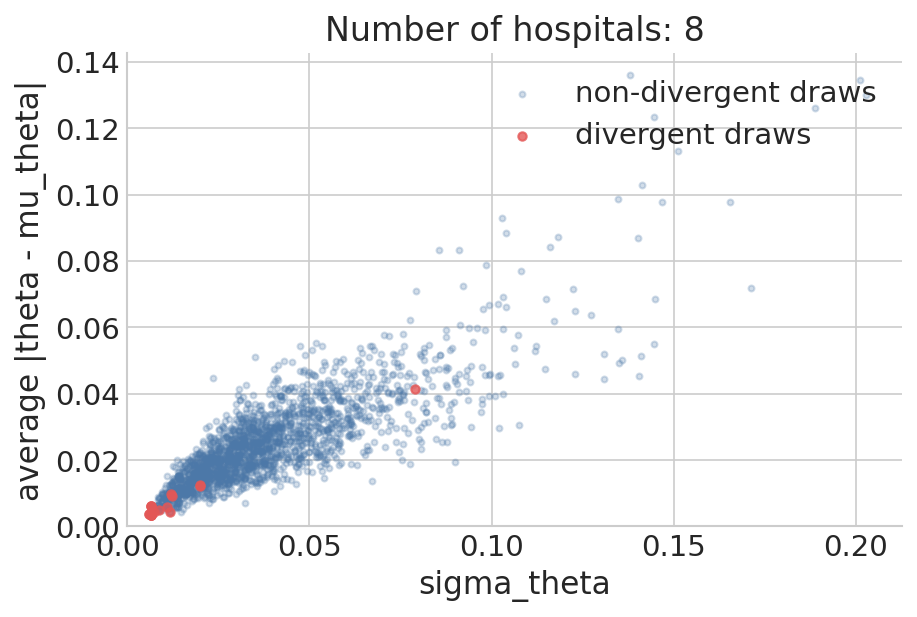

In [256]:
plot_geometry(
    idata_small_sigma,
    parameter_name="sigma_theta",
    n_hospitals=len(small_hospital_names),
    xlim=sigma_xlim,
    ylim=sigma_ylim,
)


The full data have enough information to keep both parameterizations manageable. The weak subset makes the width of the hospital distribution much less identified.

In this data set, the concentration parameterization is comparatively stable. The `sigma_theta` parameterization is more likely to show divergences because the posterior can squeeze toward very small widths, where the allowed space for the hospital-level `theta` values becomes narrow.

This is the same conceptual problem that motivates non-centered parameterizations in Normal hierarchies: separate the group offsets from the parameter that controls their scale. For the Beta hierarchy, a clean non-centered implementation requires transformations we have not introduced yet, so the workflow lesson is diagnostic:

- compare full-data and weak-data fits;
- inspect whether geometry becomes a sampling problem;
- recognize that parameterization changes HMC behavior, even when the likelihood is the same.

<a id="section-510"></a>
## 5.11 Multiple hierarchy levels

Hierarchy should follow real structure in the data. In the NYC hospital data, a true nested structure looks like city → borough → hospital. Borough is a genuine nesting level: hospitals are physically located in one borough.

The model below uses borough as the grouping variable, estimating a separate mean and concentration for each borough.

In [215]:
borough_names = pd.Index(death_data["Borough"].dropna().unique()).sort_values().to_numpy()
borough_idx = pd.Categorical(death_data["Borough"], categories=borough_names).codes
coords_group = {"data": hospital_names, "borough": borough_names}

death_data.groupby("Borough", observed=True).agg(
    hospitals=("Hospital", "count"),
    cases=("Cases", "sum"),
    deaths=("Deaths", "sum"),
    observed_rate=("DeathRate", "mean"),
)

,hospitals,cases,deaths,observed_rate
Borough,,,,
Brooklyn,13,2844,224,0.081654
Manhattan,13,2366,163,0.073639
Queens,9,2134,168,0.077517
Staten Island,3,680,62,0.097453
The Bronx,7,1211,81,0.062066


In [216]:
mu_mu_mu = float(omega_alpha / (omega_alpha + omega_beta))
nu_mu_mu = float(omega_alpha + omega_beta)

sigma_theta_group = 0.05
implied_group_theta_prior = pz.Beta(mu=mu_mu_mu, sigma=sigma_theta_group)
sigma_nu_b = float(implied_group_theta_prior.nu)
sigma_nu_mu = sigma_nu_b

pd.DataFrame({
    "parameter": ["mu_mu_mu", "nu_mu_mu", "sigma_theta_group", "sigma_nu_b", "sigma_nu_mu"],
    "value": [mu_mu_mu, nu_mu_mu, sigma_theta_group, sigma_nu_b, sigma_nu_mu],
})

,parameter,value
0,mu_mu_mu,0.141553
1,nu_mu_mu,17.248201
2,sigma_theta_group,0.050000
3,sigma_nu_b,47.606166
4,sigma_nu_mu,47.606166


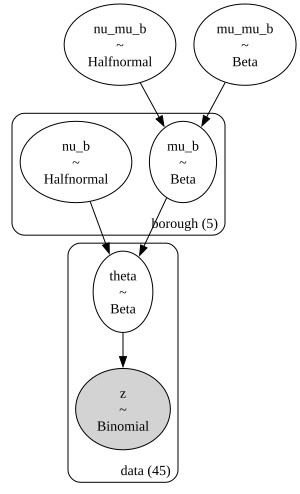

In [217]:
with pm.Model(coords=coords_group) as group_beta_binomial_model:
    mu_mu_b = pm.Beta("mu_mu_b", mu=mu_mu_mu, nu=nu_mu_mu)
    nu_mu_b = pm.HalfNormal("nu_mu_b", sigma=sigma_nu_mu)

    mu_b = pm.Beta("mu_b", mu=mu_mu_b, nu=nu_mu_b, dims="borough")
    nu_b = pm.HalfNormal("nu_b", sigma=sigma_nu_b, dims="borough")

    theta = pm.Beta("theta", mu=mu_b[borough_idx], nu=nu_b[borough_idx], dims="data")
    z = pm.Binomial("z", n=cases, p=theta, observed=deaths, dims="data")

pm.model_to_graphviz(group_beta_binomial_model)

Sampling: [mu_b, mu_mu_b, nu_b, nu_mu_b, theta, z]
C:\Users\User\AppData\Local\Temp\ipykernel_17968\2917575992.py:19: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


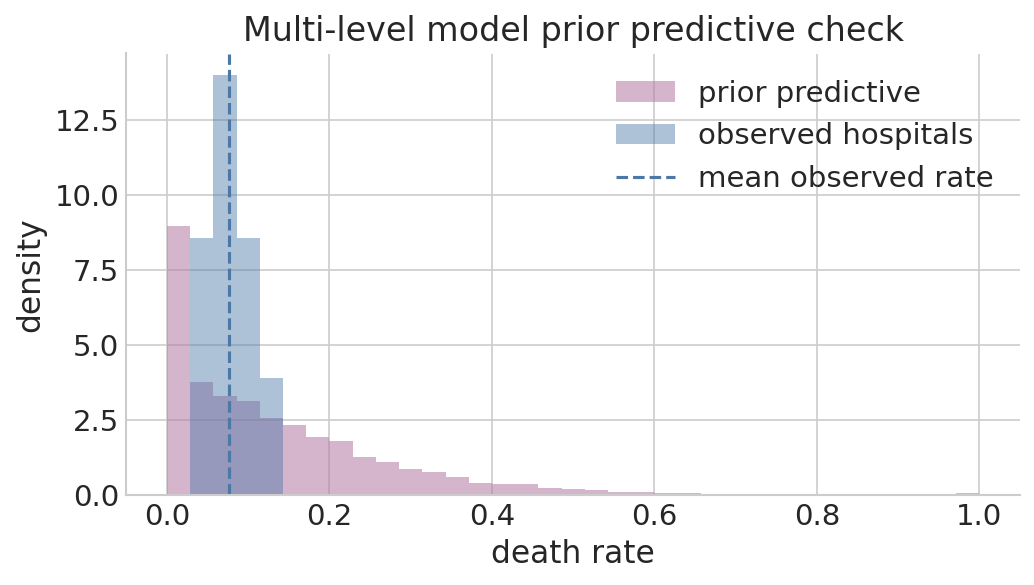

In [220]:
with group_beta_binomial_model:
    idata_group_prior = pm.sample_prior_predictive(
        samples=1000,
        random_seed=321,
    )

group_prior_z = az.extract(idata_group_prior, group="prior_predictive", var_names="z")
group_prior_death_rate = group_prior_z / cases[:, None]

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, max(0.35, group_prior_death_rate.max().item(), observed_rate.max()), 36)

ax.hist(group_prior_death_rate.to_numpy().ravel(), bins=bins, density=True, color=HIERARCHICAL_COLOR, alpha=0.55, label="prior predictive")
ax.hist(observed_rate, bins=bins, density=True, color=HOSPITAL_COLOR, alpha=0.45, label="observed hospitals")
ax.axvline(observed_rate.mean(), color=HOSPITAL_COLOR, linestyle="--", label="mean observed rate")
ax.set(xlabel="death rate", ylabel="density", title="Multi-level model prior predictive check")
ax.legend()

fig.tight_layout()

In [218]:
with group_beta_binomial_model:
    idata_group = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=456,
        progressbar=False,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_mu_b, nu_mu_b, mu_b, nu_b, theta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 33 seconds.


In [222]:
selected_group_hospitals = pd.concat(
    [
        death_data.loc[death_data["Borough"].eq("Manhattan")].head(2),
        death_data.loc[death_data["Borough"].eq("Brooklyn")].head(1),
    ]
)
selected_group_hospital_names = selected_group_hospitals["HospitalShort"].to_list()
selected_group_borough_names = selected_group_hospitals["Borough"].unique().tolist()

az.summary(
    idata_group,
    var_names=["mu_mu_b", "nu_mu_b", "mu_b", "nu_b", "theta"],
    coords={
        "borough": selected_group_borough_names,
        "data": selected_group_hospital_names,
    },
    hdi_prob=0.94,
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_mu_b,0.090,0.018,0.059,0.122,0.000,0.000,4846.0,2768.0,1.0
nu_mu_b,70.373,30.562,14.670,124.468,0.401,0.509,5301.0,2632.0,1.0
mu_b[Manhattan],0.076,0.011,0.056,0.096,0.000,0.000,5708.0,3304.0,1.0
mu_b[Brooklyn],0.085,0.011,0.067,0.105,0.000,0.000,6224.0,3135.0,1.0
nu_b[Manhattan],78.144,28.460,29.164,131.842,0.409,0.399,4470.0,2869.0,1.0
nu_b[Brooklyn],81.017,27.708,32.824,132.528,0.359,0.373,5563.0,2948.0,1.0
theta[Harlem Center],0.060,0.025,0.017,0.108,0.000,0.000,6294.0,2360.0,1.0
theta[Bellevue Center],0.047,0.016,0.020,0.077,0.000,0.000,7299.0,2874.0,1.0
theta[Wyckoff Heights MC],0.060,0.016,0.032,0.090,0.000,0.000,7344.0,2748.0,1.0


In [236]:
posterior_rate_xlim = (0.0, 0.18)
posterior_panel_figsize = (11, 3.2)


def posterior_axes_array(axes):
    return np.ravel(np.asarray(axes))


def format_posterior_axis(ax, title):
    ax.set_title(title)
    ax.set_xlim(posterior_rate_xlim)
    ax.set_xlabel("death probability")
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    return ax


def posterior_draws_for(var_name, dim_name=None, coord_value=None):
    draws = idata_group.posterior[var_name]
    if dim_name is not None:
        draws = draws.sel({dim_name: coord_value})
    return draws.to_numpy().ravel()


def posterior_legend_label(label, draws):
    hdi_low, hdi_high = az.hdi(draws, hdi_prob=0.94)
    return f"{label}: mean={draws.mean():.3f}, 94% HDI [{hdi_low:.3f}, {hdi_high:.3f}]"


mu_b_posterior_mean = idata_group.posterior["mu_b"].mean(("chain", "draw"))
best_borough = str(mu_b_posterior_mean.idxmin("borough").item())
worst_borough = str(mu_b_posterior_mean.idxmax("borough").item())
selected_performance_boroughs = [best_borough, worst_borough]

theta_group_posterior_mean = idata_group.posterior["theta"].mean(("chain", "draw")).to_series()
hospital_lookup = death_data.set_index("HospitalShort")
selected_performance_hospitals = []
selected_performance_hospital_titles = []

for borough_label, borough in [("Best borough", best_borough), ("Worst borough", worst_borough)]:
    borough_hospital_names = hospital_lookup.index[hospital_lookup["Borough"].eq(borough)]
    borough_theta_mean = theta_group_posterior_mean.loc[borough_hospital_names].sort_values()
    best_hospital = borough_theta_mean.index[0]
    worst_hospital = borough_theta_mean.index[-1]

    selected_performance_hospitals.extend([best_hospital, worst_hospital])
    selected_performance_hospital_titles.extend([
        f"{borough_label}: {best_hospital}",
        f"{borough_label}: {worst_hospital}",
    ])

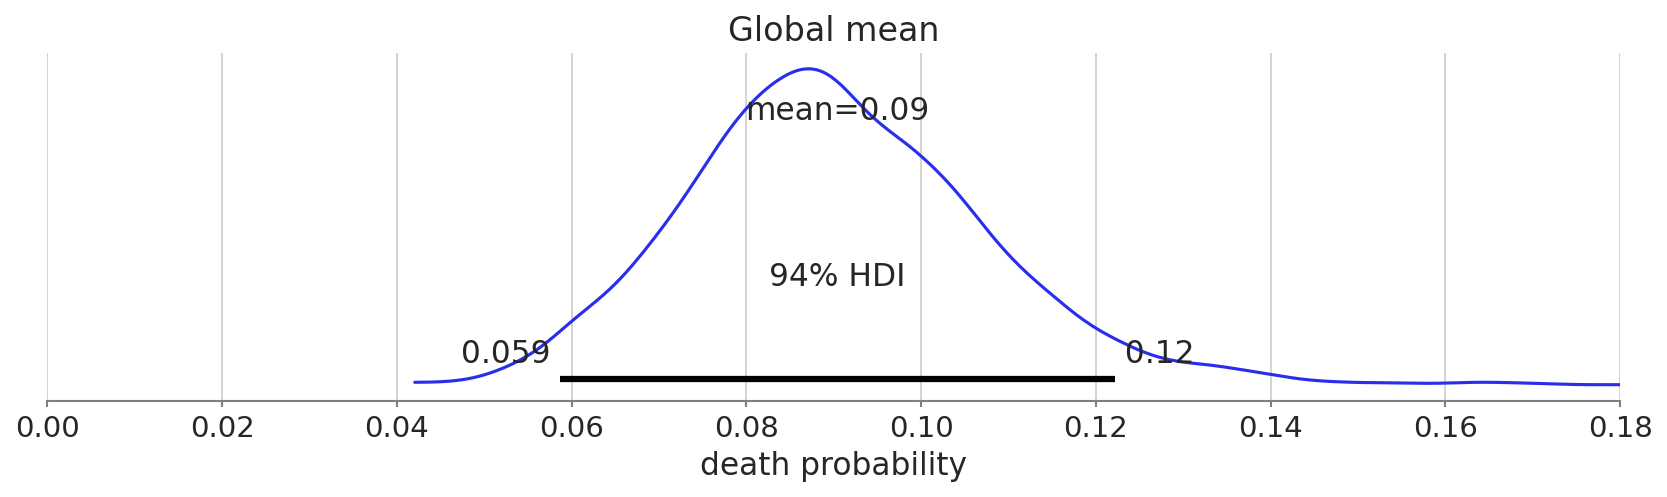

In [238]:
ax = az.plot_posterior(
    idata_group,
    var_names=["mu_mu_b"],
    hdi_prob=0.94,
    point_estimate="mean",
    figsize=posterior_panel_figsize,
    textsize=14,
)

format_posterior_axis(posterior_axes_array(ax)[0], "Global mean");

C:\Users\User\AppData\Local\Temp\ipykernel_17968\3982486795.py:24: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


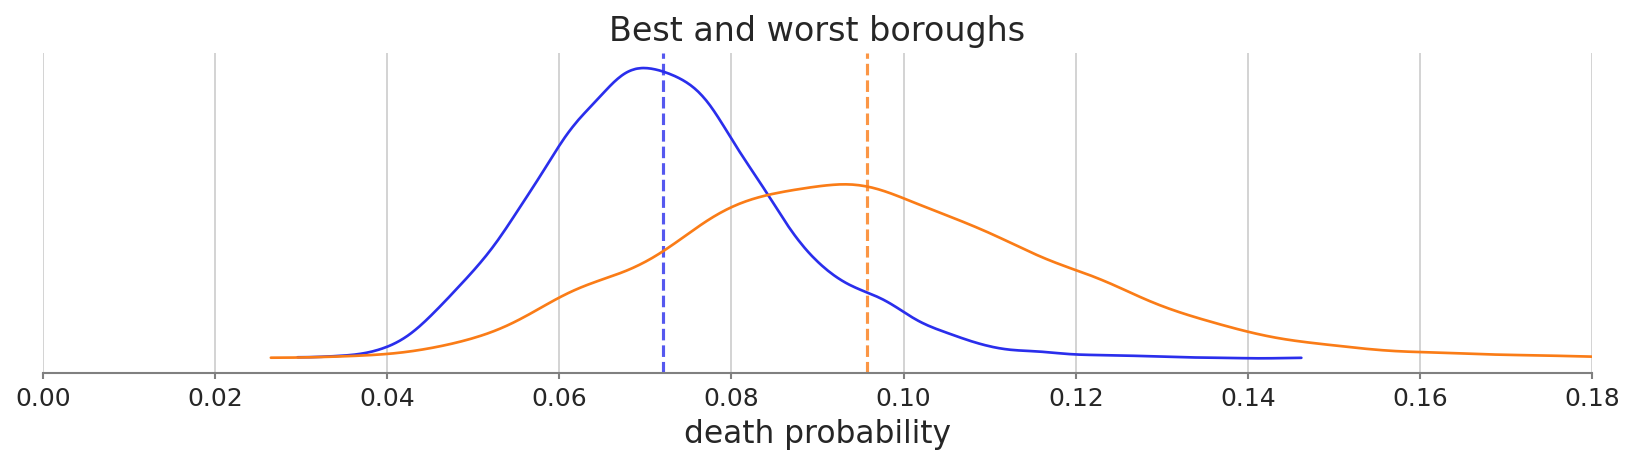

In [241]:
fig, ax = plt.subplots(figsize=posterior_panel_figsize)
handles = []
labels = []

for borough, color in zip(selected_performance_boroughs, ["C0", "C1"]):
    az.plot_posterior(
        idata_group,
        var_names=["mu_b"],
        coords={"borough": [borough]},
        hdi_prob="hide",
        point_estimate=None,
        ax=ax,
        color=color,
        textsize=12,
        show=False,
    )
    draws = posterior_draws_for("mu_b", "borough", borough)
    ax.axvline(draws.mean(), color=color, linestyle="--", linewidth=1.5, alpha=0.8)
    handles.append(ax.lines[-2])
    labels.append(posterior_legend_label(borough, draws))

format_posterior_axis(ax, "Best and worst boroughs")
# ax.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, fontsize=9)
fig.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize=posterior_panel_figsize)
hospital_colors = ["#1f77b4", "#6baed6", "#ff7f0e", "#e45756"]
handles = []
labels = []

for hospital_name, title, color in zip(
    selected_performance_hospitals,
    selected_performance_hospital_titles,
    hospital_colors,
):
    az.plot_posterior(
        idata_group,
        var_names=["theta"],
        coords={"data": [hospital_name]},
        hdi_prob="hide",
        point_estimate=None,
        ax=ax,
        color=color,
        textsize=12,
        show=False,
    )
    draws = posterior_draws_for("theta", "data", hospital_name)
    ax.axvline(draws.mean(), color=color, linestyle="--", linewidth=1.3, alpha=0.75)
    handles.append(ax.lines[-2])
    labels.append(posterior_legend_label(title, draws))

format_posterior_axis(ax, "Best and worst hospitals in selected boroughs")
# ax.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, fontsize=8)
fig.tight_layout()

In [223]:
mu_b_posterior = idata_group.posterior["mu_b"]
mu_b_hdi = az.hdi(mu_b_posterior, hdi_prob=0.94).mu_b.to_numpy()
mu_b_mean = mu_b_posterior.mean(("chain", "draw")).to_numpy()

pd.DataFrame({
    "borough": borough_names,
    "mu_b_mean": mu_b_mean,
    "mu_b_hdi_low": mu_b_hdi[:, 0],
    "mu_b_hdi_high": mu_b_hdi[:, 1],
})

,borough,mu_b_mean,mu_b_hdi_low,mu_b_hdi_high
0,Brooklyn,0.085401,0.066616,0.105364
1,Manhattan,0.076082,0.056429,0.095921
2,Queens,0.082843,0.061053,0.106346
3,Staten Island,0.095770,0.054117,0.138833
4,The Bronx,0.072095,0.046282,0.099042


This is not a causal analysis of borough effects. It is a hierarchical descriptive comparison of mortality rates by borough in these data.

<a id="section-512"></a>
## 5.12 Workflow summary

For hierarchical models, the workflow burden matters: prior predictive checks, diagnostics, posterior predictive checks, and careful interpretation are all part of the model.


After fitting, check the sampler before interpreting the borough differences.

In [ ]:
az.summary(
    idata_group,
    var_names=["mu_mu_b", "nu_mu_b", "mu_b", "nu_b"],
    hdi_prob=0.94,
)

In [ ]:
az.plot_trace(
    idata_group,
    var_names=["mu_mu_b", "mu_b"],
    compact=False,
)

Posterior predictive checks compare observed hospital death rates with replicated hospital death rates from the fitted model.

In [ ]:
with group_beta_binomial_model:
    idata_group = pm.sample_posterior_predictive(
        idata_group,
        var_names=["z"],
        random_seed=654,
        extend_inferencedata=True,
        progressbar=False,
    )

posterior_predictive_rates = idata_group.posterior_predictive["z"] / cases
posterior_predictive_hdi = az.hdi(posterior_predictive_rates, hdi_prob=0.94).z.to_numpy()
posterior_predictive_mean = posterior_predictive_rates.mean(("chain", "draw")).to_numpy()


In [ ]:
posterior_predictive_y_pos = np.arange(len(hospital_labels))

fig, ax = plt.subplots(figsize=(7, 8))
ax.hlines(posterior_predictive_y_pos, posterior_predictive_hdi[:, 0], posterior_predictive_hdi[:, 1], color=INTERVAL_COLOR, linewidth=1.5)
ax.scatter(posterior_predictive_mean, posterior_predictive_y_pos, color=HIERARCHICAL_COLOR, s=25, label="posterior predictive mean")
ax.scatter(observed_rate, posterior_predictive_y_pos, color=HOSPITAL_COLOR, marker="x", s=25, label="observed rate")
ax.set(yticks=posterior_predictive_y_pos, yticklabels=hospital_labels, xlabel="death rate", xlim=(0, 0.20))
ax.legend(loc="lower right")


In [ ]:
workflow_checks = pd.DataFrame({
    "workflow step": [
        "Pooled analysis",
        "Hospital structure",
        "Hospital hierarchy",
        "Borough hierarchy",
        "Centered vs non-centered",
        "Posterior predictive checks",
    ],
    "question": [
        "What is the overall death probability if hospital labels are ignored?",
        "How much do observed hospital rates vary, and where is uncertainty largest?",
        "How much do hospital estimates shrink toward the city-wide population?",
        "How do borough-level mean death probabilities differ after accounting for hospital-level variation?",
        "Does an alternative parameterization improve sampling geometry?",
        "Can the fitted hierarchy reproduce observed hospital-level death rates?",
    ],
})
workflow_checks


The main lesson is that hierarchy changes the target of inference. We no longer ask only for one city-wide rate or 45 unrelated hospital rates. We estimate hospital rates as related quantities, then use that structure to ask a real comparison question about borough-level mortality rates.